In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval
from astropy.table import Table, join
from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()
lines_of_interest = {
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'oiii4363': 4363.21,
}

rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}

test = ascii.read('allsources_OLD.csv')
tab = test[test['object_id']!= 'STACK']

#### STATISTICAL FITTING CORRECTION
ratio = tab['oiii5007_flux']/tab['oiii4959_flux']
mask = np.isfinite(ratio)
median = np.median(ratio[mask])
tab['oiii4959_flux'] = tab['oiii4959_flux']*(median/3)

peas = ascii.read('photometry_results.csv')

(array([ 0.,  0.,  0.,  3.,  2.,  8., 13., 36., 56., 20.,  9.,  9.,  3.,
         1.]),
 array([0.        , 0.35714286, 0.71428571, 1.07142857, 1.42857143,
        1.78571429, 2.14285714, 2.5       , 2.85714286, 3.21428571,
        3.57142857, 3.92857143, 4.28571429, 4.64285714, 5.        ]),
 <BarContainer object of 14 artists>)

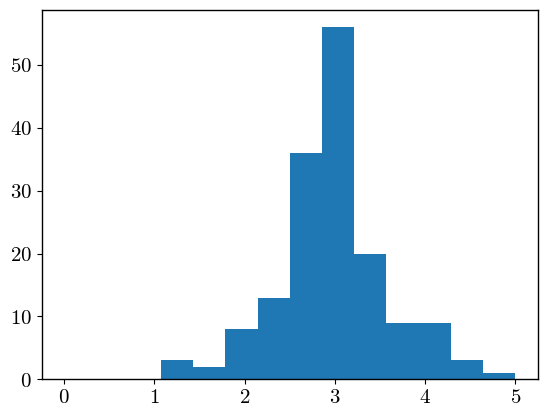

In [4]:
plt.hist(tab['oiii5007_flux']/tab['oiii4959_flux'], bins=np.linspace(0,5,15))

In [5]:
tab[tab['halpha_flux']==0]

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
28d08m00pt3s-28d52m56pt898s,28.133416666666665,-28.882471666666667,0.4354015023467077,15.836703873235557,0,1,0,8.231162179867292,0.01250512991705649,8.056100065137544,8.949025476497375e-05,6.830072333831807,0.0948235115118226,45.27279318863684,7.285106102694386,0.4127,macs0152m28,14026.49616375008,198.98911601905255,31.692392236020396,1.228062851074954,5006.84892837578,2.424432720658328,59.0211927476399,3937.4803643783985,552.9800229418195,6.2395074870529434,2.709579145518083,4958.910499580987,2.0241214752954537,48.7589003173985,16674.304063285155,136.53989441048452,25.24058553816234,1.0411862970903503,3725.9821394290025,2.2568716468864163,73.30933379552935,23036.66799975226,174.47466509379984,34.93864731293074,1.3304582610776006,3728.73573494

In [6]:
SNR_mask = ((tab['oiii5007_flux']/tab['oiii5007_flux_err'])>5)&((tab['oiii4959_flux']/tab['oiii4959_flux_err'])>5)
EW_mask = (tab['oiii5007_ew']>100)|(tab['hbeta_ew']>50)
selection = tab[SNR_mask&EW_mask].copy()

In [7]:
selection

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
38d05m01pt605s-44d20m27pt16s,38.08377916666666,-44.34087777777778,0.20850398292901562,19.3108421028434,1,0,0,9.285448803927414,0.05659444967265145,nan,nan,4.562448108492161,0.18142748904729583,68.80059323215505,17.964798000821027,0.282,rxj0232m44,40925.353055070475,713.3367134115044,119.83157456301223,5.705059708947216,5006.839379458619,2.5157799115966744,61.44322861986223,14370.841192420952,1853.6646968710384,21.343318197791106,8.512590400463738,4958.9777774400845,2.268575320848984,55.39919802788287,0.0,0.0,nan,nan,3726.03,1.0,24.400668213494743,0.0,0.0,nan,nan,3728.82,1.0,24.382410999599827,26979.13459314359,192.62347564093636,300.1046400915456,4.104142326262138,6562.735248383178,2.8184398606266465,52.96109372536083,11796.361212599046,174.72

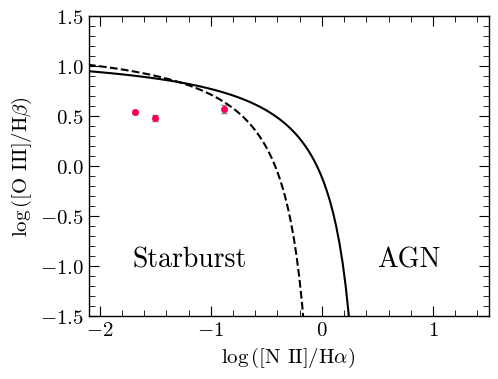

In [8]:
fig, ax = pf.create_plot()

ax.set_xlabel(r'$\log$([N II]/H$\alpha$)')
ax.set_ylabel(r'$\log$([O III]/H$\beta$)')

xvals = np.log10(selection['nii6583_flux']/selection['halpha_flux'])
yvals = np.log10(selection['oiii5007_flux']/selection['hbeta_flux'])

xerr = np.abs(xvals*np.sqrt( (selection['nii6583_flux_err']/selection['nii6583_flux'])**2 + (selection['halpha_flux_err']/selection['halpha_flux'])**2 ))
yerr = np.abs(yvals*np.sqrt( (selection['oiii5007_flux_err']/selection['oiii5007_flux'])**2 + (selection['hbeta_flux_err']/selection['hbeta_flux'])**2 ))

classf = lr.classify_bpt(xvals,yvals)
markers = ['o','x','^']
colors = ['#ff004f', "#77aca2", "#0359c3"]


for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)
    ax.errorbar(xvals[mask],yvals[mask], fmt=markers[i], yerr=yerr[mask], color=colors[i], ms=4, ecolor='gray', capsize=2)
ax.set_xlim(-2.1,1.5)
ax.set_ylim(-1.5,1.5)

grid = np.linspace(-2.5,0, 100)
grid2 = np.linspace(-2.5,.3, 100)

ax.plot(grid,lr.kauffmann03(grid),color='k', ls='--')
ax.plot(grid2,lr.kewley01(grid2),color='k')

ax.text(-1.7,-1,'Starburst', fontsize=20)
ax.text(0.5,-1,'AGN', fontsize=20)

pf.fix_plot([ax])
fig.savefig(f'figs/bpt.png', dpi=600, bbox_inches='tight')

In [9]:
Table(selection[0]).write('peas_test.csv', overwrite=True)

In [10]:
selection[0]

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
38d05m01pt605s-44d20m27pt16s,38.08377916666666,-44.34087777777778,0.20850398292901562,19.3108421028434,1,0,0,9.285448803927414,0.05659444967265145,nan,nan,4.562448108492161,0.18142748904729583,68.80059323215505,17.964798000821027,0.282,rxj0232m44,40925.353055070475,713.3367134115044,119.83157456301223,5.705059708947216,5006.839379458619,2.5157799115966744,61.44322861986223,14370.841192420952,1853.6646968710384,21.343318197791106,8.512590400463738,4958.9777774400845,2.268575320848984,55.39919802788287,0.0,0.0,nan,nan,3726.03,1.0,24.400668213494743,0.0,0.0,nan,nan,3728.82,1.0,24.382410999599827,26979.13459314359,192.62347564093636,300.1046400915456,4.104142326262138,6562.735248383178,2.8184398606266465,52.96109372536083,11796.361212599046,174.72

In [11]:
selection[np.argmax(selection['oiii5007_ew'])]

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
4d46m35pt34s-20d26m04pt362s,4.776483333333333,-20.434545,0.5281643173109969,33.71796440119023,0,0,0,nan,nan,9.127627555086473,0.001353397172330448,5.649086981654453,0.3040330069783813,49.040615570484825,12.796590573888835,0.277,s26,6228.778788338162,125.74057611634852,7201.58220092841,397.0880821684763,5006.842189217474,1.8072016208162445,42.36500403453211,2132.211411996372,246.26683275814784,29.77024844148575,10.632162576843369,4958.889660661423,1.5720692222085526,36.13790830715717,519.5547382476107,69.42891045430139,22.599612508345185,15.20375418087949,3726.8932408166543,0.9954335156241744,24.18170367425463,521.4307065079821,69.7206795456017,22.71120063428617,15.267646664755185,3728.786784119692,0.9954335156241744,24.163610295316744,0.0,0.0,

In [12]:
selection.sort('oiii5007_flux')

In [13]:
selection

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
8d37m02pt79s2d24m57pt689s,8.617441666666666,2.416024722222222,0.5133134583394461,32.79382826391661,0,0,0,nan,nan,8.021302428493389,0.0031076903268883464,7.104372224276769,0.6858963970434612,55.00161327586024,13.712465380921362,0.388,macs0034p02a,1052.5139050743378,68.35888650935955,23.85661439265894,4.232223853891691,5006.7973657659295,1.472387938930396,32.93712583067687,889.1649675167921,105.37678659874335,15.042744544164607,5.511990677949504,4959.200344149392,3.2688320595104683,81.97397029700586,1452.9104324573043,112.52555502740711,75.65800937072412,29.51831605834613,3725.9584959438557,1.5103119309747066,45.72666546021663,2181.8506807327344,143.41893364343912,113.82464867608545,37.62243528598357,3728.5816573871507,1.5103119309747066,45.6924

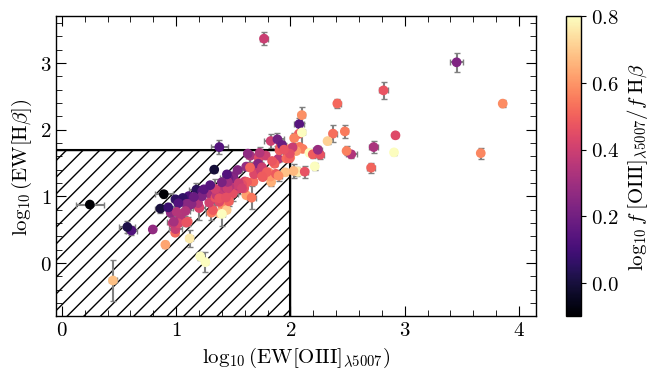

In [14]:
fig, ax = pf.create_plot((6,3))
err_x = 0.434*(tab['oiii5007_ew_err']/(tab['oiii5007_ew']))
err_y = 0.434*np.abs(tab['hbeta_ew_err']/(tab['hbeta_ew']))

oiiihbeta = np.log10(tab['oiii5007_flux']/tab['hbeta_flux'])

ax.errorbar(np.log10(tab['oiii5007_ew']),np.log10(tab['hbeta_ew']), yerr= err_y, xerr=err_x, fmt='o', ecolor='gray', capsize=2, mfc='none', mec='none')
cbar = ax.scatter(np.log10(tab['oiii5007_ew']),np.log10(tab['hbeta_ew']), c=oiiihbeta, zorder=10, cmap='magma', vmin=-0.1,vmax=0.8)
plt.colorbar(cbar, label=r'$\log_{10}f\;$[OIII]$_{\lambda5007}/f\;$H$\beta$')

ax.set_xlabel(r'$\log_{10}($EW[OIII]$_{\lambda5007}$)')
ax.set_ylabel(r'$\log_{10}($EW[H$\beta$])')

ax.set_xlim(-0.05, 4.15)
ax.set_ylim(-0.8, 3.7)

ax.vlines(2,-100,np.log10(50),color='k')
ax.hlines(np.log10(50),-100,2,color='k')
ax.fill_between([-100,2],-100,np.log10(50), facecolor='white', edgecolor='black', zorder=-10, hatch='//')

pf.fix_plot([ax])
fig.savefig(f'figs/populations.png', dpi=600, bbox_inches='tight')

In [15]:
grapes = tab[(tab['halpha_flux']>0)&(tab['oiii5007_ew']>100)]
grapes.sort('oiii5007_flux')
grapes[-2]

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
38d04m12pt825s-44d21m10pt642s,38.070229166666664,-44.35295611111111,0.40292640529351553,66.73403958150307,0,0,0,8.969458542722732,0.0071141320617926825,8.150940159413311,0.0002622770955946467,8.162632124545151,0.2310792637281556,52.167125686054774,11.366223970474508,0.282,rxj0232m44,22567.1412073046,354.6168687556022,128.08897740369298,5.497713979981577,5006.834015829306,1.9980823399660776,47.58586696794032,7700.771516946474,933.7871419981336,19.408720732766298,7.277460935748094,4958.849131583009,1.7838306402540278,42.122918614158394,9815.98386042128,333.47237723449535,31.03228480758622,5.3098464551879445,3726.2293091856905,2.2526145560741524,73.15631758124707,11807.609335391948,374.7664395449063,37.404139444223546,5.967367573421555,3729.12559

In [16]:
candidate = grapes[-2]
cluster = candidate['name']
print(cluster)
loc = '/Volumes/Expansion/exp_thardy/cubes/'+cluster+'_COMBINED_CUBE_MED_FINAL.fits'
with fits.open(loc) as hdul:
    cx,cy = (hdul[1].header['CRVAL1'],hdul[1].header['CRVAL2'])
    cent = SkyCoord(cx,cy, unit = u.deg)

galloc = SkyCoord(candidate['ra'], candidate['dec'], unit=u.deg)
cube_ift = ift.museCube(loc, cent.ra.deg,cent.dec.deg)
cluster = Cube(loc)
linefits = cube_ift.pick_target(galloc,candidate['z'],0.7,plot=False)

spectrum_o = cube_ift.spectra.get(list(cube_ift.spectra.keys())[0])
rest_spectrum = cube_ift.rest_spectra.get(list(cube_ift.spectra.keys())[0])

freq = np.linspace(rest_spectrum.get_start(), rest_spectrum.get_end(), rest_spectrum.shape[0])
redshift = cube_ift.ex_table['z'][0]

wave_rest = rest_spectrum.wave.coord()  # Angstroms
flux = rest_spectrum.data*1e-20            # erg/s/cm^2/Angstrom (check units)
flux_unc = np.sqrt(rest_spectrum.var*1e-20)   # Get std deviation from variance

rxj0232m44


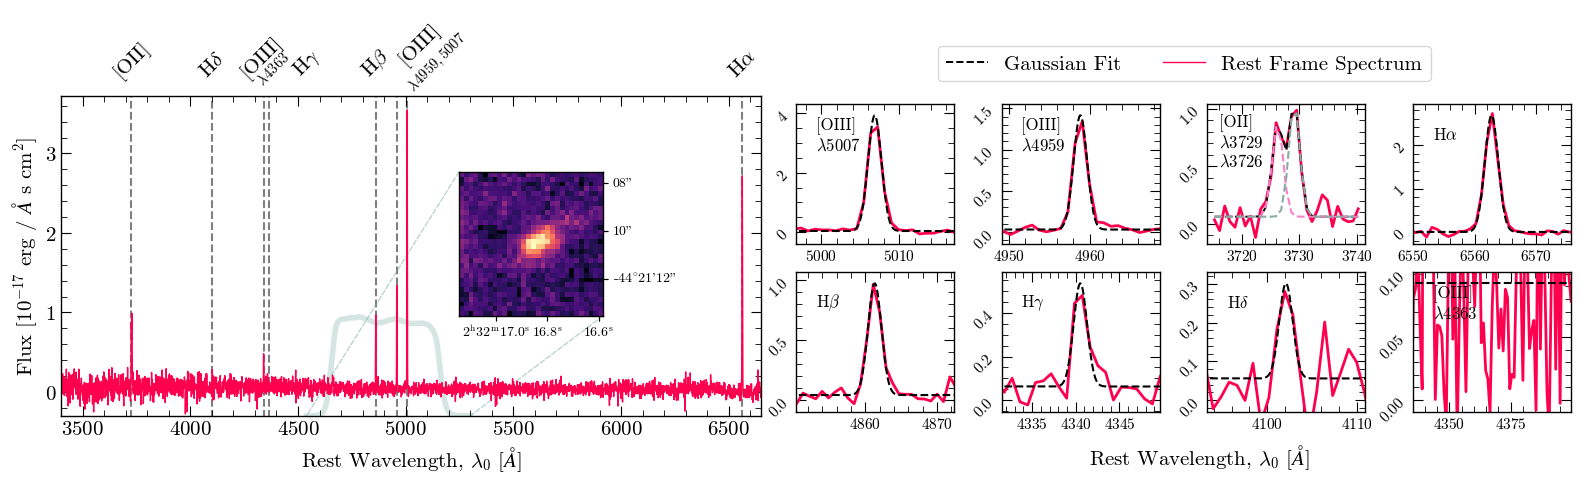

In [17]:
fig, axes_grid = plt.subplots(2,4,
                              figsize=(10,4))
plt.subplots_adjust(hspace=0.2, wspace=0.3)

specax = fig.add_axes((-.61,.1,.7,.8))

ax_flat = axes_grid.flatten()
all_ax = np.append(ax_flat,specax)

specax.set_xlabel(r'Rest Wavelength, $\lambda_0$ [$\AA$]')
specax.set_ylabel(r'Flux $[10^{-17}$ erg / $\AA$ s cm$^2]$')
ax_flat[-3].set_xlabel(r'Rest Wavelength, $\lambda_0$ [$\AA$]')
ax_flat[-3].xaxis.set_label_coords(1.25,-.22)

for ax in ax_flat:
    ax.tick_params('y', rotation=45, labelsize=11)
    ax.tick_params('x', labelsize=11)

#### PLOT SPECTRUM ####

specax.plot(freq, rest_spectrum.data/1000, color='#ff004f', lw=1, label='Rest Frame Spectrum')

max_peak_y = np.max(rest_spectrum.data)/1000*1.05
specax.set_ylim(-.3,max_peak_y)
specax.set_xlim(3400,6650)

line_names = list(cube_ift.rest_lambdas.keys())

for l in list(lines_of_interest.keys()):
    wl = rest_lambdas.get(l)
    name = lambda_keys.get(l)
    # print(name)
    specax.vlines(wl, -10,10, linestyle = 'dashed', zorder=-10, color='k', alpha=0.5)
    fac = 1.05
    if ('oiii49' in l) or ('oiii5' in l):
        name = '[OIII]\n'+r'$_{\lambda4959,5007}$'
        wl += 100
        fac = 1
    if 'oiii4959' in l:
        name = ''
    if 'oii3' in l:
        name = '[OII]'
    if 'hgamma' in l:
        wl += 200
    if l == 'oiii4363':
        name  = '[OIII]\n'+r'$^{\lambda4363}$'
        fac = 1
    specax.text(wl, max_peak_y * fac, name, ha='center', va='bottom', rotation=45, fontsize=15)

##### PLOT PHOTOMETRY AND PASSBAND #####

gsubcube = cluster.subcube((galloc.dec.deg, galloc.ra.deg),6)
bandpass = ascii.read('HST_WFC3_UVIS2.F689M.dat', names=['lambda','bp'])
image = gsubcube.bandpass_image(bandpass['lambda'], bandpass['bp'])

photax = fig.add_axes((-0.23,0.35,0.18,0.36), projection=image.wcs.wcs)
photax.imshow(image.data, cmap='magma')
for i in range(2):
    photax.coords[i].set_ticks(number=3)
    photax.coords[i].set_ticklabel(size=10)
    photax.coords[i].set_ticks_position('br')
    photax.coords[i].set_axislabel('')
    photax.coords[i].tick_params(rotation=45)

photax.coords[1].set_separator((r'$^{\circ}$', "'", '"'))
photax.coords[0].set_separator((r'$^{\mathrm{h}}$', r'$^{\mathrm{m}}$',r'$^{\mathrm{s}}$'))

specax.plot(bandpass['lambda']/(1+redshift), (bandpass['bp']*5-.3), lw=4, zorder=-10, alpha=0.3, color='#77aca2')

x_start = bandpass['lambda'][0] / (1 + redshift)
y_start = bandpass['bp'][0] * 5 - 0.3
x_end = bandpass['lambda'][-1] / (1 + redshift)
y_end = bandpass['bp'][-1] * 5 - 0.3

con_left = ConnectionPatch(
    xyA=(0, 1),                      # Bottom-left of photax
    coordsA=photax.transAxes,
    xyB=(x_start, y_start),
    coordsB=specax.transData,
    color='#77aca2',
    linestyle='--',
    linewidth=1,
    alpha=0.5
)

con_right = ConnectionPatch(
    xyA=(1, 0),                      # Bottom-right of photax
    coordsA=photax.transAxes,
    xyB=(x_end, y_end),
    coordsB=specax.transData,
    color='#77aca2',
    linestyle='--',
    linewidth=1,
    alpha=0.5
)

specax.add_artist(con_left)
specax.add_artist(con_right)

#### NOW PLOT SPECTRA

linefits = []
linenames = list(lines_of_interest.keys())

for i,l in enumerate(linenames):
    ax = ax_flat[i]
    linename = linenames[i]
    if linename == 'oii3726':
        oii3726_fit, oii3729_fit, fit_model = cube_ift.fit_oii_doublet(rest_spectrum, plot=False, id='00', verbose=True)
        linefits.append(oii3726_fit)
        linefits.append(oii3729_fit)


    # def plot_oii_doublet(self, sub_spec, fit_model, id):
        lmin, lmax = 3715, 3740
        sub_spec = rest_spectrum.subspec(lmin=lmin, lmax=lmax)
        wave = sub_spec.wave.coord()
        ax.plot(wave, sub_spec.data/1000, color='#ff004f', lw=2)        
        
    #     # Plot full model
        ax.plot(wave, fit_model(wave)/1000, color='k', lw=1.4, label='Gaussian Fit', ls='--')
        
    #     # Plot individual components
        g1 = fit_model[0]
        g2 = fit_model[1]
        cont = fit_model[2]
        ax.plot(wave, (g1(wave) + cont(wave))/1000, ls='--', color="#f97eca")
        ax.plot(wave, (g2(wave) + cont(wave))/1000, ls='--', color='#88aca2')
        # ax.legend(fontsize=9)
        ax.text(3716, 0.5,
                '[OII]\n'+'$\lambda3729$'+'\n'+'$\lambda3726$', size=12)
        


    else:
        linefit = cube_ift.fit_line(rest_spectrum, linename)
        linefits.append(linefit)

        profile = cube_ift.generate_gaussian_profile(linefit, 500, 25)

        ax.plot(freq, rest_spectrum.data/1000, color='#ff004f', lw=2)
        ax.plot(profile[0], profile[1]/1000, color='k', lw=1.5, ls='--')

        ax.set_xlim(profile[0][150], profile[0][350])
        ax.set_ylim(-0.1*np.max(profile[1]/1000), 1.1*np.max(profile[1]/1000))

        name = lambda_keys.get(linename)
        fact = 0.8
        if 'lambda' in name:
            oiii = name[:6]
            wl = name[7:]
            name = oiii+'\n'+wl
            fact=0.7
        ax.text(profile[0][175], fact*np.max(profile[1]/1000),name, size=12)
    

fig.legend(bbox_to_anchor=(0.77, 1.05),ncols=2)

pf.fix_plot(all_ax)
# pf.fix_plot([photax], tickdir='out')
fig.savefig(f'figs/fitting.png', dpi=600, bbox_inches='tight')

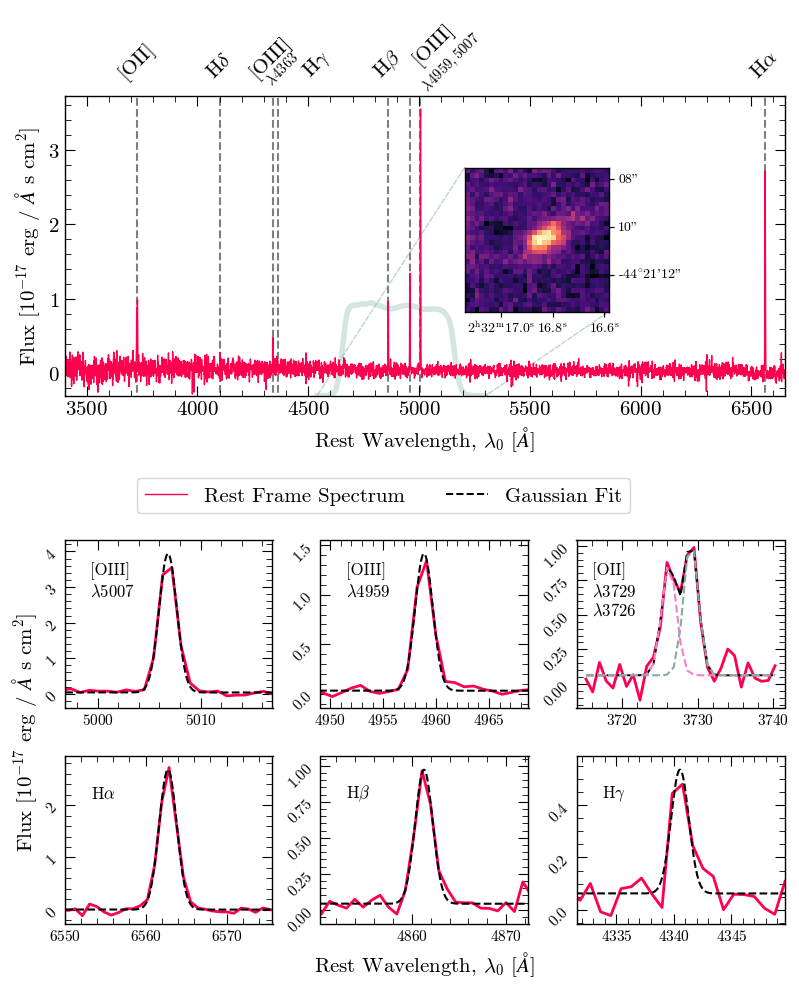

In [37]:
fig = plt.figure(figsize=(8, 12))

# Top: full spectrum axes spanning full width
specax = fig.add_axes((0.05, 0.5, 0.9, 0.25))

# Bottom: 2x3 grid of line fit panels beneath specax
n_cols = 3
n_rows = 2
left_margin = 0.05
right_margin = 0.95
bottom_margin = 0.06
top_margin = 0.38
hspace = 0.04
wspace = 0.06

total_width = right_margin - left_margin
total_height = top_margin - bottom_margin
panel_w = (total_width - wspace * (n_cols - 1)) / n_cols
panel_h = (total_height - hspace * (n_rows - 1)) / n_rows

ax_flat = []
for row in range(n_rows):
    for col in range(n_cols):
        left = left_margin + col * (panel_w + wspace)
        bottom = top_margin - (row + 1) * panel_h - row * hspace
        ax = fig.add_axes((left, bottom, panel_w, panel_h))
        ax_flat.append(ax)

ax_flat = np.array(ax_flat)
all_ax = np.append(ax_flat, specax)

specax.set_xlabel(r'Rest Wavelength, $\lambda_0$ [$\AA$]')
specax.set_ylabel(r'Flux $[10^{-17}$ erg / $\AA$ s cm$^2]$')
ax_flat[-2].set_xlabel(r'Rest Wavelength, $\lambda_0$ [$\AA$]')

for ax in ax_flat:
    ax.tick_params('y', rotation=45, labelsize=11)
    ax.tick_params('x', labelsize=11)

#### PLOT SPECTRUM ####

specax.plot(freq, rest_spectrum.data/1000, color='#ff004f', lw=1, label='Rest Frame Spectrum')

max_peak_y = np.max(rest_spectrum.data)/1000*1.05
specax.set_ylim(-.3, max_peak_y)
specax.set_xlim(3400, 6650)

line_names = list(cube_ift.rest_lambdas.keys())

for l in list(lines_of_interest.keys()):
    wl = rest_lambdas.get(l)
    name = lambda_keys.get(l)
    specax.vlines(wl, -10, 10, linestyle='dashed', zorder=-10, color='k', alpha=0.5)
    fac = 1.05
    if ('oiii49' in l) or ('oiii5' in l):
        name = '[OIII]\n'+r'$_{\lambda4959,5007}$'
        wl += 100
        fac = 1
    if 'oiii4959' in l:
        name = ''
    if 'oii3' in l:
        name = '[OII]'
    if 'hgamma' in l:
        wl += 200
    if l == 'oiii4363':
        name  = '[OIII]\n'+r'$^{\lambda4363}$'
        fac = 1
    specax.text(wl, max_peak_y * fac, name, ha='center', va='bottom', rotation=45, fontsize=15)

##### PLOT PHOTOMETRY AND PASSBAND #####

gsubcube = cluster.subcube((galloc.dec.deg, galloc.ra.deg), 6)
bandpass = ascii.read('HST_WFC3_UVIS2.F689M.dat', names=['lambda', 'bp'])
image = gsubcube.bandpass_image(bandpass['lambda'], bandpass['bp'])

photax = fig.add_axes((0.55, 0.5, 0.18, 0.26), projection=image.wcs.wcs)
photax.imshow(image.data, cmap='magma')
for i in range(2):
    photax.coords[i].set_ticks(number=3)
    photax.coords[i].set_ticklabel(size=10)
    photax.coords[i].set_ticks_position('br')
    photax.coords[i].set_axislabel('')
    photax.coords[i].tick_params(rotation=45)

photax.coords[1].set_separator((r'$^{\circ}$', "'", '"'))
photax.coords[0].set_separator((r'$^{\mathrm{h}}$', r'$^{\mathrm{m}}$', r'$^{\mathrm{s}}$'))

specax.plot(bandpass['lambda']/(1+redshift), (bandpass['bp']*5-.3), lw=4, zorder=-10, alpha=0.3, color='#77aca2')

x_start = bandpass['lambda'][0] / (1 + redshift)
y_start = bandpass['bp'][0] * 5 - 0.3
x_end = bandpass['lambda'][-1] / (1 + redshift)
y_end = bandpass['bp'][-1] * 5 - 0.3

con_left = ConnectionPatch(
    xyA=(0, 1),
    coordsA=photax.transAxes,
    xyB=(x_start, y_start),
    coordsB=specax.transData,
    color='#77aca2',
    linestyle='--',
    linewidth=1,
    alpha=0.5
)

con_right = ConnectionPatch(
    xyA=(1, 0),
    coordsA=photax.transAxes,
    xyB=(x_end, y_end),
    coordsB=specax.transData,
    color='#77aca2',
    linestyle='--',
    linewidth=1,
    alpha=0.5
)

specax.add_artist(con_left)
specax.add_artist(con_right)

#### NOW PLOT SPECTRA ####

# Remove hdelta and oiii4363 from the loop
lines_to_plot = {k: v for k, v in lines_of_interest.items() if k not in ('hdelta', 'oiii4363')}

linefits = []
linenames = list(lines_to_plot.keys())

for i, l in enumerate(linenames):
    ax = ax_flat[i]
    linename = linenames[i]
    if linename == 'oii3726':
        oii3726_fit, oii3729_fit, fit_model = cube_ift.fit_oii_doublet(rest_spectrum, plot=False, id='00', verbose=True)
        linefits.append(oii3726_fit)
        linefits.append(oii3729_fit)

        lmin, lmax = 3715, 3740
        sub_spec = rest_spectrum.subspec(lmin=lmin, lmax=lmax)
        wave = sub_spec.wave.coord()
        ax.plot(wave, sub_spec.data/1000, color='#ff004f', lw=2)
        ax.plot(wave, fit_model(wave)/1000, color='k', lw=1.4, label='Gaussian Fit', ls='--')

        g1 = fit_model[0]
        g2 = fit_model[1]
        cont = fit_model[2]
        ax.plot(wave, (g1(wave) + cont(wave))/1000, ls='--', color="#f97eca")
        ax.plot(wave, (g2(wave) + cont(wave))/1000, ls='--', color='#88aca2')
        ax.text(3716, 0.5, '[OII]\n'+'$\lambda3729$'+'\n'+'$\lambda3726$', size=12)

    else:
        linefit = cube_ift.fit_line(rest_spectrum, linename)
        linefits.append(linefit)

        profile = cube_ift.generate_gaussian_profile(linefit, 500, 25)

        ax.plot(freq, rest_spectrum.data/1000, color='#ff004f', lw=2)
        ax.plot(profile[0], profile[1]/1000, color='k', lw=1.5, ls='--')

        ax.set_xlim(profile[0][150], profile[0][350])
        ax.set_ylim(-0.1*np.max(profile[1]/1000), 1.1*np.max(profile[1]/1000))

        name = lambda_keys.get(linename)
        fact = 0.8
        if 'lambda' in name:
            oiii = name[:6]
            wl = name[7:]
            name = oiii+'\n'+wl
            fact = 0.7
        ax.text(profile[0][175], fact*np.max(profile[1]/1000), name, size=12)

# Vertical label spanning both rows of the line fit grid
grid_label_x = left_margin - 0.05
grid_label_y = (bottom_margin + top_margin) / 2
fig.text(grid_label_x, grid_label_y,
         r'Flux $[10^{-17}$ erg / $\AA$ s cm$^2]$',
         ha='center', va='center', rotation=90,
         fontsize=specax.yaxis.label.get_size())

fig.legend(bbox_to_anchor=(0.77, 0.44), ncols=2)

pf.fix_plot(all_ax)
fig.savefig(f'figs/fittingnew.png', dpi=600, bbox_inches='tight')

In [ ]:


fig, ax = pf.create_plot()
ax2 = fig.add_axes((1.025,0,0.1,1))
specax = fig.add_axes((0,1.05,1,0.2))
specax.set_ylabel('Flux\n[Norm]', fontsize=12)
specax.set_xlabel(r'Rest Wavelength, $\lambda_0$ [$\AA$]')
specax.xaxis.tick_top()
specax.xaxis.set_label_position('top') 
specax.set_xlim(4800,5100)
specax.set_xticklabels(specax.get_xticklabels(),fontsize=12)
specax.set_yticks([])

ax.set_xlabel(r'$\log$([N II]/H$\alpha$)')
ax.set_ylabel(r'$\log$([O III]/H$\beta$)')

xvals = np.log10(tab['nii6583_flux']/tab['halpha_flux'])
yvals = np.log10((tab['oiii5007_flux']+tab['oiii4959_flux'])/tab['hbeta_flux'])

xerr = np.abs(xvals*np.sqrt( (tab['nii6583_flux_err']/tab['nii6583_flux'])**2 + (tab['halpha_flux_err']/tab['halpha_flux'])**2 ))
yerr = np.abs(yvals*np.sqrt( (tab['oiii5007_flux_err']/tab['oiii5007_flux'])**2 + (tab['hbeta_flux_err']/tab['hbeta_flux'])**2 ))

peamask = (SNR_mask&EW_mask)

classf = lr.classify_bpt(xvals,yvals)
markers = ['o','x','^']
colors = ['#ff004f', "#77aca2", "#0359c3"]

text_coords = -1.5,0

transition = []
transition_pea_coords = None # ADDED: To store coordinates of the transition pea

for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)
    print(len(xvals[mask]))

    # hbetaDISP = np.log10(tab['hbeta_vel_disp'][mask])
    hbetaDISP = tab['hbeta_vel_disp'][mask]


    ax.errorbar(xvals[mask],yvals[mask], fmt='none', yerr=yerr[mask], ms=4, ecolor='gray', capsize=2)
    # sc = ax.scatter(xvals[mask],yvals[mask], marker = markers[i], c=hbetaDISP, s=20, zorder=10, cmap='magma_r', vmax=2, vmin=1.6)
    sc = ax.scatter(xvals[mask],yvals[mask], marker = markers[i], c=hbetaDISP, s=20, zorder=10, cmap='magma_r', vmax=10, vmin=150)

    # fig.colorbar(sc, ax=ax,cax=ax2, label=r'log($V($ H$\beta$ [kms$^{-1}$] )) ')
    fig.colorbar(sc, ax=ax,cax=ax2, label=r'$V($ H$\beta$ [kms$^{-1}$] ) ')

    current_peamask = mask&peamask
    if key == 'transition':
        transition.append(tab[peamask][0])
        # ADDED: Store the coordinates of the transition pea if it exists
        if np.any(current_peamask):
            transition_pea_coords = (xvals[current_peamask][0], yvals[current_peamask][0])

    ax.scatter(xvals[current_peamask],yvals[current_peamask], s=150, marker='s', edgecolors='#777777', c='None', linewidths=2)

    pea_x_coords = xvals[current_peamask]
    pea_y_coords = yvals[current_peamask]

    for pea_x, pea_y in zip(pea_x_coords, pea_y_coords):
        arrow = FancyArrowPatch(
            (text_coords[0], text_coords[1]),
            (pea_x, pea_y),
            arrowstyle='->,head_length=5,head_width=3',
            connectionstyle="arc3,rad=.2",
            color='k',
            linestyle='-',
            linewidth=2,
            zorder=15,
            shrinkA=10, 
            shrinkB=5  
        )
        ax.add_patch(arrow)
shift = 0.4
ax.text(text_coords[0]-shift,text_coords[1],'EELGs', fontsize=15)


ax.set_xlim(-2.1,.6)
ax.set_ylim(-.55,1.5)

grid = np.linspace(-2.5,0, 100)
grid2 = np.linspace(-2.5,.3, 100)

ax.plot(grid,lr.kauffmann03(grid),color='k', ls='--')
ax.plot(grid2,lr.kewley01(grid2),color='k')

ax.text(-1.7,-.3,'Starburst', fontsize=20)
ax.text(0.01,-.3,'AGN', fontsize=20, bbox=dict(facecolor='white', edgecolor='none', zorder=10))
# ax2.set_ylim([40,100])

###### PLOT THE SPECTRUM ########

galloc, cube_ift, cluster, spectrum_o, rest_spectrum = ift.get_fromIFU(transition[0])
specax.plot(rest_spectrum.wave.coord(), rest_spectrum.data, color='#ff004f', lw=1, label='Rest Frame Spectrum')

# --- NEW CODE TO CONNECT SPEC AXIS TO SQUARE ---
if transition_pea_coords is not None:
    # This is an estimate of the half-size of the square marker in data coordinates.
    # The marker size `s=150` is in points^2. This conversion is an approximation.
    square_half_side = 0.04

    pea_x, pea_y = transition_pea_coords

    # Define the top corners of the square on the main plot (ax)
    top_left_corner_ax = (pea_x - square_half_side, pea_y + square_half_side)
    top_right_corner_ax = (pea_x + square_half_side, pea_y + square_half_side)

    # Get the limits of the spectrum plot (specax) to connect the lines to its bottom edge
    spec_xmin, spec_xmax = specax.get_xlim()
    spec_ymin = specax.get_ylim()[0]

    # Define the connection points on the bottom of the spectrum plot
    bottom_left_specax = (spec_xmin, spec_ymin)
    bottom_right_specax = (spec_xmax, spec_ymin)

    # Create the connection lines (patches)
    con1 = ConnectionPatch(
        xyA=bottom_left_specax, xyB=top_left_corner_ax,
        coordsA="data", coordsB="data", axesA=specax, axesB=ax,
        color="gray", linestyle="-", lw=3, zorder=1, alpha=0.3
    )
    con2 = ConnectionPatch(
        xyA=bottom_right_specax, xyB=top_right_corner_ax,
        coordsA="data", coordsB="data", axesA=specax, axesB=ax,
        color="gray", linestyle="-", lw=3, zorder=1, alpha=0.3
    )

    # Add the connection lines to the figure
    fig.add_artist(con1)
    fig.add_artist(con2)
# --- END OF NEW CODE ---
specax.set_zorder(20)

pf.fix_plot([ax,ax2, specax])
fig.savefig(f'figs/bpt_vel_wPeas1.png', dpi=600, bbox_inches='tight')

In [ ]:
def get_R23(sel):
    R23 = ((sel['oiii5007_flux']+sel['oiii4959_flux']+sel['oii3726_flux']+sel['oii3729_flux'])/sel['hbeta_flux']).data
    num_r23 = np.array((sel['oiii5007_flux'],sel['oiii4959_flux'],sel['oii3726_flux'],sel['oii3729_flux']))
    num_r23_err = np.array((sel['oiii5007_flux_err'],sel['oiii4959_flux_err'],sel['oii3726_flux_err'],sel['oii3729_flux_err']))
    R23_err = (np.sqrt((np.sqrt(np.sum(num_r23_err**2,axis=0))/np.sum(num_r23, axis=0))**2 + (sel['hbeta_flux_err'].data/sel['hbeta_flux'].data)**2)*R23)
    return R23, R23_err

R23, R23_err = get_R23(selection)

# def get_O32(sel):
#     num_o32 = np.array([sel['oiii5007_flux'],sel['oiii4959_flux']])
#     num_o32_err = np.array([sel['oiii5007_flux_err'],sel['oiii4959_flux_err']])
#     denom_o32 = np.array([sel['oii3729_flux'],sel['oii3726_flux']])
#     denom_o32_err = np.array([sel['oii3729_flux_err'],sel['oii3726_flux_err']])
#     O32 = np.sum(num_o32, axis=0)/np.sum(denom_o32, axis=0)
#     O32_err = np.sqrt((np.sqrt(np.sum(num_o32_err**2, axis=0))/np.sum(num_o32, axis=0))**2+(np.sqrt(np.sum(denom_o32_err**2, axis=0))/np.sum(denom_o32, axis=0))**2)*O32
#     return O32, O32_err

def get_O32(sel):
    num_o32 = np.array(sel['oiii5007_flux'])
    num_o32_err = np.array(sel['oiii5007_flux_err'])
    denom_o32 = np.array([sel['oii3729_flux'],sel['oii3726_flux']])
    denom_o32_err = np.array([sel['oii3729_flux_err'],sel['oii3726_flux_err']])
    O32 = num_o32/np.sum(denom_o32, axis=0)
    O32_err = np.sqrt((num_o32_err/num_o32)**2+(np.sqrt(np.sum(denom_o32_err**2, axis=0))/np.sum(denom_o32, axis=0))**2)*O32
    return O32, O32_err

O32, O32_err = get_O32(selection)

SNRmask = (O32/O32_err>5)&(R23/R23_err>5)

In [ ]:
fig, ax = pf.create_plot(size=(3.5,3))
ax2 = fig.add_axes((1.025,0,0.1,1))

ax.errorbar(np.log10(R23)[SNRmask],np.log10(O32)[SNRmask], xerr=(0.43*R23_err/R23)[SNRmask], yerr=(0.43*O32_err/O32)[SNRmask], fmt='o', color='none', ecolor='grey', capsize=2)
scatter = ax.scatter(np.log10(R23)[SNRmask],np.log10(O32)[SNRmask], c=np.log10(selection['oiii5007_ew'])[SNRmask],zorder=10, vmax=4, vmin=0.5, cmap='magma')
plt.colorbar(scatter, cax=ax2, label=r'$\log_{10}($ EW[OIII]$_{\lambda5007})$ ')

ax.set_xlim(0.57, 1.19)

textx = 1.13
shuffle = 0.013
ax.text(textx,-.3, 'Increasing Ionisation', rotation=90, fontsize=13,zorder=20, bbox=dict(facecolor='white', edgecolor='none', zorder=20))

arrow = FancyArrowPatch((textx+shuffle,-.7),(textx+shuffle,0.86), 
            arrowstyle='->,head_length=8,head_width=4',
            color='k',
            linestyle='-',
            linewidth=2,
            zorder=10,
            shrinkA=10, 
            shrinkB=5,
        )
ax.add_artist(arrow)

ax.set_xlabel(r'$\log_{10} $R$23$')
ax.set_ylabel(r'$\log_{10} $O$32$')

pf.fix_plot([ax, ax2])
fig.savefig(f'figs/R23O32.png', dpi=600, bbox_inches='tight')

In [ ]:
aurora_mask = selection['oiii4363_flux']>0
apeas = selection[aurora_mask]

In [ ]:
def get_t1(oiii_4959, oiii_5007, oiii_4363, CT):
    return 1.432/((np.log10((oiii_4959+oiii_5007)/oiii_4363)) - np.log10(CT))

def get_CT(t):
    return 8.44 - 1.09*t + 0.5*t**2 - 0.08*t**3

In [ ]:
# t_init = 10
# t_diff=np.ones_like(apeas['oiii4959_flux'])*10
# t_history = []

# while (t_diff[np.isfinite(t_diff)] > 0.001).any():
#     t0 = t_init
#     CT = get_CT(t0)
#     t1 = get_t1(apeas['oiii4959_flux'],
#                     apeas['oiii5007_flux'],
#                     apeas['oiii4363_flux'],
#                     CT)
#     t_diff = np.abs((t0-t1)/(t0+1e-18))
#     t_init = t1
#     t_history.append(t1)

# test = np.array(t_history)
# for walker in test.T:
#     # print(walker.shape)
#     plt.plot(walker)

# plt.xlim(0,10)

In [ ]:
def get_CT(t):
    return 8.44 - 1.09*t + 0.5*t**2 - 0.08*t**3

def get_t1(oiii_4959, oiii_5007, oiii_4363, CT):
    return 1.432/((np.log10((oiii_4959+oiii_5007)/oiii_4363)) - np.log10(CT))

# --- Main Solver Logic ---

def solve_temperature(apeas, t_initial_guess, tol=1e-4):

    def objective_function(t, oiii4959, oiii5007, oiii4363):
        CT = get_CT(t)
        t_new = get_t1(oiii4959, oiii5007, oiii4363, CT)
        penalizer = 1 if (t_new<0).any() else 0
        return (t - t_new)+penalizer

    # Package the arguments for the solver
    args_for_solver = (apeas['oiii4959_flux'],
                       apeas['oiii5007_flux'],
                       apeas['oiii4363_flux'])

    # Call the solver
    solution = root(objective_function,
                    t_initial_guess,
                    args=args_for_solver,
                    method='hybr',  # A good, robust default method
                    tol=tol)
    
    return solution

In [ ]:
soln = solve_temperature(apeas, np.ones_like(apeas['hbeta_flux']))
t3 = soln.x
t2 = -0.577+t3*(2.065-0.498*t3)
mcityoplus = np.log10((apeas['oii3726_flux']+apeas['oii3729_flux'])/apeas['hbeta_flux']) +5.961+1.676/t2-0.4*np.log10(t2)-0.034*t2+np.log10(1+1.35*1e-1*t3**(-0.5))
mcityoplusplus = np.log10((apeas['oiii5007_flux']+apeas['oiii4959_flux'])/apeas['hbeta_flux']) + 6.200 + 1.251/t3 - 0.55*np.log10(t3)-0.014*np.log10(t3)

logOH12 = np.log10(10**(mcityoplus-12)+10**(mcityoplusplus-12))+12

In [ ]:
selection['Z_dir_gen'] = np.ones_like(selection['z'])*1.031492
selection['Z_dir_gen_err'] = np.ones_like(selection['z'])*1.031492
selection['direct'] = np.ones_like(selection['z'])

selection_mask = (selection['hdelta_flux']>0)&(selection['oii3726_flux']>0)&(selection['oii3729_flux']>0)&(selection['hgamma_flux']>0)&(selection['hbeta_flux']>0)&(selection['oiii5007_flux']>0)&(selection['oiii4959_flux']>0)
selection_new = selection[selection_mask]
i=0

for p in selection_new:
    i+=1
    # print(i)
    input_dict = {}
    input_dict['redshift'] =  p['z']
    input_dict['OII']      = [p['oii3726_flux']+p['oii3729_flux'],np.sqrt(np.sum(np.array([p['oii3726_flux_err'],p['oii3729_flux_err']])**2))]
    input_dict['Hdelta']   = [p['hdelta_flux'], p['hdelta_flux_err']]
    input_dict['Hgamma']   = [p['hgamma_flux'], p['hgamma_flux_err']]
    input_dict['Hbeta']    = [p['hbeta_flux'], p['hbeta_flux_err']]
    input_dict['O4959']    = [p['oiii4959_flux'],p['oiii4959_flux_err']]
    input_dict['O5007']    = [p['oiii5007_flux'],p['oiii5007_flux_err']]
    input_dict['Hbeta_EW'] = [p['hbeta_ew'], p['hbeta_ew_err']]

    direct = 0
    if p['oiii4363_flux']>0:
        input_dict['O4363'] = [p['oiii4363_flux'],p['oiii4363_flux_err']]
        direct = 1

    try:
        galaxy = genesis_metallicity(input_dict)
        p['Z_dir_gen'] = galaxy.metallicity.n
        p['Z_dir_gen_err'] = galaxy.metallicity.s
        p['direct'] = direct
    except:
        print('failed')
        p['Z_dir_gen'] = np.nan
        p['Z_dir_gen_err'] = np.nan
        p['direct'] = np.nan

In [ ]:
R23_sub, R23_sub_e = get_R23(selection_new)
O32_sub, O32_sub_e = get_O32(selection_new)

combx = R23_sub-0.08*O32_sub
comberr = (np.sqrt(R23_sub_e**2+O32_sub_e**2)/combx)*0.434

fig, ax = pf.create_plot()
ax2 = fig.add_axes((1.025,0,0.2,1))

ax2.yaxis.tick_right()
ax2.yaxis.set_label_position('right') 

colors = ['#77aca2', '#ff004f']
markers = ['^','v']
labels = 'Calibrated',r'Direct T$_e$'

for i in range(2):
    mask = selection_new['direct']==i

    scatter = ax.errorbar(np.log10(combx)[mask], selection_new['Z_dir_gen'][mask], 
                          xerr=comberr[mask], yerr=selection_new['Z_dir_gen_err'][mask], 
                          capsize=2, ecolor='gray', color=colors[i], fmt=markers[i], ms=8, label=labels[i])

ax2.hist(selection_new['z']-selection_new['zcluster'], orientation='horizontal', bins=np.linspace(0,0.6,9), lw=2, color="#ffb46a", histtype='step')
ax2.set_ylabel(r'$z-z_{\mathrm{cluster}}$')

ax.set_xlabel(r'$\log_{10}\,\mathrm{R}23-0.08\mathrm{O}32$ [dex]')
ax.set_ylabel(r'$12+\log_{10} \mathrm{O}/\mathrm{H}$ [dex]')

ax.legend(fontsize=12)

ax.set_xlim(0.62,1.065)
ax.set_ylim(7.38,9.15)

selection_new_hasZ = selection_new[np.isfinite(selection_new['Z_dir_gen'])]
selection_new_hasZ.sort('Z_dir_gen')
select = [selection_new_hasZ[0],selection_new_hasZ[-1]]

specaxes = []
AB = ['A','B']

for i,s in enumerate(select):
    objid = s['object_id']

    galloc, cube_ift, cluster, spectrum_o, rest_spectrum = ift.get_fromIFU(s)
    print(objid)
    
    specax = fig.add_axes((0,1.05*(1.+0.35*i),1,0.3))

    specaxes.append(specax)

    if i == 0 :
        plt.setp(specax.get_xticklabels(), visible=False)
        specax.xaxis.tick_top()
        specax.tick_params(labelsize=12, labeltop=False, labelbottom=False)
    else:
        specax.set_xlabel(r'Rest Wavelength, $\lambda_0$ [$\AA$]')
        specax.xaxis.set_label_position('top') 
        # specax.set_xticklabels(specax.get_xticklabels(),fontsize=12, loc='to')
        specax.tick_params(labelsize=12, labeltop=True, labelbottom=False)

    # specax.set_yticks([])
    specax.set_ylabel('Flux\n[Norm]', fontsize=12)
    specax.set_xlim(4800,5100)

    specax.plot(rest_spectrum.wave.coord(), rest_spectrum.data/1000, lw=2,color=colors[i])
    # print(s['Z_dir_gen'])
    isthispea = selection_new['object_id'] == objid
    coords = (np.log10(combx)[isthispea],selection_new['Z_dir_gen'][isthispea])
    ax.scatter(coords[0], coords[1], s=400, marker='s', edgecolors='#777777', c='None', linewidths=2)
    print(coords[1], s['Z_dir_gen_err'])

    ax.text(coords[0]-0.01, (coords[1]+(-1)**i*(0.2)-0.05), AB[i], fontsize=20)

    fig.text(1.1,1.05*(1.+0.35*i)+0.1, AB[i], fontsize=30)

ax.hlines(8.65,-100,100, colors="#949494", lw=3, alpha=0.3)
ax.hlines(8.0,-100,100, colors="#949494", lw=3, alpha=0.3)

ax.text(0.7,8.6,r'$Z_{\odot}$', color='#777777', fontsize=15, bbox=dict(facecolor='white', edgecolor='none', zorder=10))

ax.text(0.66,7.98,r'Very Metal-Poor', color='#777777', fontsize=12, bbox=dict(facecolor='white', edgecolor='none', zorder=10))

pf.fix_plot([ax,ax2, *specaxes])
fig.savefig(f'figs/mcities.png', dpi=600, bbox_inches='tight')

In [ ]:
O32_sub_e

In [ ]:
selection_new

In [ ]:
peas.sort('flux_Spitzer_I2_4.5')

In [ ]:
cont_est = peas['flux_HST_F435W']+peas['flux_HST_F606W']+peas['flux_HST_F814W']
spit_est = peas['flux_Spitzer_I1_3.6']+peas['flux_Spitzer_I2_4.5']

def get_log10err(tab, key):
    return 0.434*tab[key+'_err']/tab[key]

fig, ax = pf.create_plot()
ax2 = fig.add_axes((0,1.05,1,0.3), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
ax3 = fig.add_axes((1.025,0,0.1,1))

ax.errorbar(np.log10(selection['oiii5007_flux']),peas['flux_Spitzer_I2_4.5'], xerr=get_log10err(selection, 'oiii5007_flux'),
             fmt='^', color="#a8064a", yerr=np.abs(peas['flux_Spitzer_I2_4.5'])/10, ecolor='gray', capsize=2, label='4.6$\mu$')
ax.errorbar(np.log10(selection['oiii5007_flux']),peas['flux_Spitzer_I1_3.6'],xerr=get_log10err(selection, 'oiii5007_flux', ),label='3.6$\mu$',
             fmt='v', color="#00838f", yerr=np.abs(peas['flux_Spitzer_I1_3.6'])/10, ecolor='gray', capsize=2)


Nselection_new = selection[~selection_mask]
sc = ax2.scatter(np.log10(Nselection_new['oiii5007_flux']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[~selection_mask], color="#768f88", marker='x', s=20)

sc = ax2.scatter(np.log10(selection_new['oiii5007_flux']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[selection_mask], 
                 c=selection_new['Z_dir_gen'], cmap='magma_r', vmin=7.3)
plt.colorbar(sc, cax=ax3, label=r'$12+\log_{10} \mathrm{O}/\mathrm{H}$ [dex]')
ax2.set_ylim(0.1,4.5)

ax.set_ylim(0,16)
ax.set_xlim(3.2)
ax.legend(title='IRAC-CH')

ax.set_xlabel(r'$\log_{10}(\,F([OIII]$, [$\times10^{-20}$ erg / cm$^{2}$ s])')
ax.set_ylabel('Spitzer Flux [$\mu$Jy]')

ax2.set_ylabel('CH2/CH1')


pf.fix_plot([ax,ax2,ax3])
fig.savefig(f'figs/irac.png', dpi=600, bbox_inches='tight')

In [ ]:
selection[selection['object_id']=='8d28m41pt88s-7d51m59pt549s']

In [ ]:
# velocitydisp**2 against metallicity - M/R vs metallicity we expect more massive more metallicity
# OIII EW against metallicity - this is like a star formation tracer so we expect low metallicity to be highest SFR galaxies

fig, ax = pf.create_plot((3,3))
ax2 = fig.add_axes((1.05,0,1,1),sharey=ax)
ax3 = fig.add_axes((2.1,0,1,1),sharey=ax)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
ax.set_ylabel(r'$12+\log_{10} \mathrm{O}/\mathrm{H}$ [dex]')
axes= [ax,ax2,ax3]

Z_det = selection_new['Z_dir_gen']

#### FIRSTLY SFR
ax.set_xlabel(r'$\log_{10}$ SFR [M$_{\odot}\,$yr$^{-1}$]')
ldists = cosmo.luminosity_distance(selection_new['z']).to(u.cm).value
L_hbeta = (ldists**2)*np.pi*4*selection_new['hbeta_flux']*2e-19
SFR = 7.9*1e-42*L_hbeta*2.86
log10SFR_err = (selection_new['hbeta_flux_err']/selection_new['hbeta_flux'])*0.434

for i in range(2):
    mask = selection_new['direct']==i

    scatter = ax.errorbar(np.log10(SFR)[mask], Z_det[mask], 
                          xerr=log10SFR_err[mask], yerr=selection_new['Z_dir_gen_err'][mask], 
                          capsize=2, ecolor='gray', color=colors[i], fmt=markers[i], ms=8, label=labels[i])

#### THEN DISPERSION
ax2.set_xlabel(r'$\log_{10}$(V[OIII], $\sigma$, [km s$^{-1}$])$^2$')

xvals = (selection_new['oiii5007_vel_disp'])**2

for i in range(2):
    mask = selection_new['direct']==i

    scatter = ax2.errorbar(np.log10(xvals)[mask], Z_det[mask], 
                          xerr=log10SFR_err[mask], yerr=selection_new['Z_dir_gen_err'][mask], 
                          capsize=2, ecolor='gray', color=colors[i], fmt=markers[i], ms=8, label=labels[i])

#### THEN OIII EW
ax3.set_xlabel(r'$\log_{10}$ EW[OIII]')

xvals = (selection_new['oiii5007_ew'])

for i in range(2):
    mask = selection_new['direct']==i

    scatter = ax3.errorbar(np.log10(xvals)[mask], Z_det[mask], 
                          xerr=log10SFR_err[mask], yerr=selection_new['Z_dir_gen_err'][mask], 
                          capsize=2, ecolor='gray', color=colors[i], fmt=markers[i], ms=8, label=labels[i])

# ax.scatter(selection_new[''])


for i,a in enumerate(axes):
    xpos = a.get_xlim()
    a.set_xlim(*xpos)

    dx = xpos[1]-xpos[0]

    a.hlines(8.65,-100,100, colors="#949494", lw=3, alpha=0.3)
    a.hlines(8.00,-100,100, colors="#C2C2C2", lw=3, alpha=0.3)


    if i==0:
       a.text(xpos[0]+dx/4,8.6,r'$Z_{\odot}$', color='#777777', fontsize=15, bbox=dict(facecolor='white', edgecolor='none', zorder=10))
       a.text(xpos[1]-dx/2.2,7.98,r'Very Metal-Poor', color='#777777', fontsize=12, bbox=dict(facecolor='white', edgecolor='none', zorder=10))
    
ax3.legend()

pf.fix_plot([ax,ax2,ax3])
fig.savefig(f'figs/physicals.png', dpi=600, bbox_inches='tight')

In [ ]:
(selection_new['hbeta_flux_err']/selection_new['hbeta_flux'])

In [ ]:
tab

In [ ]:
plt.hist(tab['oiii5007_flux']/tab['halpha_flux'], np.linspace(0,3,20))

In [ ]:
peas[peas['flux_Spitzer_I1_3.6']==0] = np.nan
peas[peas['flux_Spitzer_I2_4.5']==0] = np.nan


cont_est = peas['flux_HST_F435W']+peas['flux_HST_F606W']+peas['flux_HST_F814W']
spit_est = peas['flux_Spitzer_I1_3.6']+peas['flux_Spitzer_I2_4.5']

def get_log10err(tab, key):
    return 0.434*tab[key+'_err']/tab[key]

def pnm(flux, a=0.01, b=0.2):
    return np.sqrt(a * np.abs(1/flux)*50 + b**2)

def get_log10err2(val, err):
    """Calculates the error in log10 space."""
    return np.abs(0.434 * err / val)

fig, ax = pf.create_plot()
ax2 = fig.add_axes((0,1.05,1,0.3), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
ax3 = fig.add_axes((1.025,0,0.1,1))

spitzer_flux_err_3_6 = pnm(peas['flux_Spitzer_I1_3.6'])
spitzer_flux_err_4_5 = np.abs(pnm(peas['flux_Spitzer_I2_4.5']))

logspitzer_flux_err_4_5 = get_log10err2(peas['flux_Spitzer_I2_4.5'],spitzer_flux_err_4_5)
logspitzer_flux_err_3_6 = get_log10err2(peas['flux_Spitzer_I1_3.6'],spitzer_flux_err_3_6)



# ax.errorbar(np.log10(selection['oiii5007_flux']),peas['flux_Spitzer_I2_4.5'], xerr=get_log10err(selection, 'oiii5007_flux'),
#              fmt='^', color="#a8064a", yerr=spitzer_flux_err_4_5, ecolor='gray', capsize=2, label='4.6$\mu$')
# ax.errorbar(np.log10(selection['oiii5007_flux']),peas['flux_Spitzer_I1_3.6'],xerr=get_log10err(selection, 'oiii5007_flux', ),label='3.6$\mu$',
#              fmt='v', color="#00838f", yerr=spitzer_flux_err_3_6, ecolor='gray', capsize=2)

ax.errorbar(np.log10(selection['oiii5007_flux']),np.log10(peas['flux_Spitzer_I2_4.5']), xerr=get_log10err(selection, 'oiii5007_flux'),
             fmt='^', color="#a8064a", yerr=logspitzer_flux_err_4_5, ecolor='gray', capsize=2, label='4.5$\mu$')
ax.errorbar(np.log10(selection['oiii5007_flux']),np.log10(peas['flux_Spitzer_I1_3.6']),xerr=get_log10err(selection, 'oiii5007_flux', ),label='3.6$\mu$',
             fmt='v', color="#00838f", yerr=logspitzer_flux_err_3_6, ecolor='gray', capsize=2)


Nselection_new = selection[~selection_mask]
sc = ax2.scatter(np.log10(Nselection_new['oiii5007_flux']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[~selection_mask], color="#768f88", marker='x', s=20)

sc = ax2.scatter(np.log10(selection_new['oiii5007_flux']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[selection_mask], 
                 c=selection_new['Z_dir_gen'], cmap='magma_r', vmin=7.3)
plt.colorbar(sc, cax=ax3, label=r'$12+\log_{10} \mathrm{O}/\mathrm{H}$ [dex]')
ax2.set_ylim(0.1,4.5)

# ax.set_ylim(0,16)
ax.set_ylim(0,1.5)
ax.set_xlim(3.2)
ax.legend(title='IRAC-CH')

ax.set_xlabel(r'$\log_{10}(\,F([OIII]$, [$\times10^{-20}$ erg / cm$^{2}$ s])')
# ax.set_ylabel('Spitzer Flux [$\mu$Jy]')
ax.set_ylabel(r'$\log_{10}($Spitzer Flux [$\mu$Jy])')

ax2.set_ylabel('CH2/CH1')


pf.fix_plot([ax,ax2,ax3])
fig.savefig(f'figs/irac.png', dpi=600, bbox_inches='tight')

In [ ]:
redshifts = selection['z']
lum_dist_cm = cosmo.luminosity_distance(redshifts).to(u.cm).value

oiii_flux_cgs = selection['oiii5007_flux'] * 1e-20
oiii_lum = oiii_flux_cgs * 4 * np.pi * lum_dist_cm**2

spitzer_flux_3_6_cgs = peas['flux_Spitzer_I1_3.6'] * 1e-6 * 1e-23
spitzer_flux_4_5_cgs = peas['flux_Spitzer_I2_4.5'] * 1e-6 * 1e-23

l_nu_3_6 = spitzer_flux_3_6_cgs * 4 * np.pi * lum_dist_cm**2
l_nu_4_5 = spitzer_flux_4_5_cgs * 4 * np.pi * lum_dist_cm**2

c_cm_s = 2.998e10  # Speed of light in cm/s
nu_3_6 = c_cm_s / (3.6 * 1e-4)  # 3.6 microns in cm
nu_4_5 = c_cm_s / (4.5 * 1e-4)  # 4.5 microns in cm

spitzer_lum_3_6 = nu_3_6 * l_nu_3_6
spitzer_lum_4_5 = nu_4_5 * l_nu_4_5

oiii_lum_err = get_log10err2(selection['oiii5007_flux'], selection['oiii5007_flux_err'])

spitzer_lum_3_6_err = get_log10err2(peas['flux_Spitzer_I1_3.6'], spitzer_flux_err_3_6)
spitzer_lum_4_5_err = get_log10err2(peas['flux_Spitzer_I2_4.5'], spitzer_flux_err_4_5)


fig, ax = pf.create_plot()
ax2 = fig.add_axes((0, 1.05, 1, 0.3), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
ax3 = fig.add_axes((2.05, 0, 0.1, 1))
ax4 = fig.add_axes((1.025,0,1,1), sharey=ax)
plt.setp(ax4.get_yticklabels(), visible=False)
ax5 = fig.add_axes((1.025, 1.05, 1, 0.3), sharex=ax4, sharey=ax2)
plt.setp(ax5.get_xticklabels(), visible=False)
plt.setp(ax5.get_yticklabels(), visible=False)


ax.errorbar(np.log10(oiii_lum), np.log10(spitzer_lum_4_5),
             xerr=oiii_lum_err, yerr=(spitzer_lum_4_5_err),
             fmt='^', color="#a8064a", ecolor='gray', capsize=2, label='4.5$\mu$m')
ax.errorbar(np.log10(oiii_lum), np.log10(spitzer_lum_3_6),
             xerr=oiii_lum_err, yerr=spitzer_lum_3_6_err,
             fmt='v', color="#00838f", ecolor='gray', capsize=2, label='3.6$\mu$m')


lum_ratio = spitzer_lum_4_5 / spitzer_lum_3_6
log_oiii_lum_total = np.log10(oiii_lum)

ax2.scatter(log_oiii_lum_total[~selection_mask], lum_ratio[~selection_mask],
            color="#768f88", marker='x', s=20)

sc = ax2.scatter(log_oiii_lum_total[selection_mask], lum_ratio[selection_mask],
                 c=selection_new['Z_dir_gen'], cmap='magma_r', vmin=7.3)

ax4.errorbar(np.log10(selection['oiii5007_ew']), np.log10(spitzer_lum_4_5),
             xerr=0.01, yerr=(spitzer_lum_4_5_err),
             fmt='^', color="#a8064a", ecolor='gray', capsize=2, label='4.5$\mu$m')
ax4.errorbar(np.log10(selection['oiii5007_ew']), np.log10(spitzer_lum_3_6),
             xerr=0.01, yerr=spitzer_lum_3_6_err,
             fmt='v', color="#00838f", ecolor='gray', capsize=2, label='3.6$\mu$m')

ax5.scatter(np.log10(selection['oiii5007_ew'])[~selection_mask], lum_ratio[~selection_mask],
            color="#768f88", marker='x', s=20)

sc = ax5.scatter(np.log10(selection['oiii5007_ew'])[selection_mask], lum_ratio[selection_mask],
                 c=selection_new['Z_dir_gen'], cmap='magma_r', vmin=7.3)




# Colorbar and Labels
plt.colorbar(sc, cax=ax3, label=r'$12+\log_{10} \mathrm{O}/\mathrm{H}$ [dex]')
ax.legend(title='IRAC-CH')

ax.set_xlabel(r'$\log_{10}(\,L([\mathrm{OIII}])$ [erg s$^{-1}$])')
ax.set_ylabel(r'$\log_{10}(\,L_{\nu} \nu)$ [erg s$^{-1}$])')
ax2.set_ylabel(r'$L(4.5\mu\mathrm{m})/$'+'\n'+r'$L(3.6\mu\mathrm{m})$')
ax4.set_xlabel(r'$\log_{10}(\,EW([\mathrm{OIII}])$ [$\AA$])')

# Set plot limits (adjust as needed, as luminosity scale differs from flux)
ax2.set_ylim(-1, 4) # Ratio might stay in a similar range
# ax.set_xlim(...) # Autoscaled
# ax.set_ylim(...) # Autoscaled

ax4.set_xlim(1.67,3.95)

# Finalize and save the plot
pf.fix_plot([ax, ax2, ax3,ax4,ax5])
fig.savefig(f'figs/irac2.png', dpi=600, bbox_inches='tight')

In [ ]:
redshifts = selection['z']
lum_dist_cm = cosmo.luminosity_distance(redshifts).to(u.cm).value

oiii_flux_cgs = selection['oiii5007_flux'] * 1e-20
oiii_lum = oiii_flux_cgs * 4 * np.pi * lum_dist_cm**2

spitzer_flux_3_6_cgs = peas['flux_Spitzer_I1_3.6'] * 1e-6 * 1e-23
spitzer_flux_4_5_cgs = peas['flux_Spitzer_I2_4.5'] * 1e-6 * 1e-23

l_nu_3_6 = spitzer_flux_3_6_cgs * 4 * np.pi * lum_dist_cm**2
l_nu_4_5 = spitzer_flux_4_5_cgs * 4 * np.pi * lum_dist_cm**2

c_cm_s = 2.998e10  # Speed of light in cm/s
nu_3_6 = c_cm_s / (3.6 * 1e-4)  # 3.6 microns in cm
nu_4_5 = c_cm_s / (4.5 * 1e-4)  # 4.5 microns in cm

spitzer_lum_3_6 = nu_3_6 * l_nu_3_6
spitzer_lum_4_5 = nu_4_5 * l_nu_4_5

oiii_lum_err = get_log10err2(selection['oiii5007_flux'], selection['oiii5007_flux_err'])

spitzer_lum_3_6_err = get_log10err2(peas['flux_Spitzer_I1_3.6'], spitzer_flux_err_3_6)
spitzer_lum_4_5_err = get_log10err2(peas['flux_Spitzer_I2_4.5'], spitzer_flux_err_4_5)


fig, ax = pf.create_plot()
ax2 = fig.add_axes((0, 1.05, 1, 0.3), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
ax3 = fig.add_axes((2.05, 0, 0.1, 1))
ax4 = fig.add_axes((1.025,0,1,1), sharey=ax)
plt.setp(ax4.get_yticklabels(), visible=False)
ax5 = fig.add_axes((1.025, 1.05, 1, 0.3), sharex=ax4, sharey=ax2)
plt.setp(ax5.get_xticklabels(), visible=False)
plt.setp(ax5.get_yticklabels(), visible=False)


ax.errorbar(np.log10(oiii_lum), np.log10(spitzer_lum_4_5),
             xerr=oiii_lum_err, yerr=(spitzer_lum_4_5_err),
             fmt='^', color="#a8064a", ecolor='gray', capsize=2, label='4.5$\mu$m')
ax.errorbar(np.log10(oiii_lum), np.log10(spitzer_lum_3_6),
             xerr=oiii_lum_err, yerr=spitzer_lum_3_6_err,
             fmt='v', color="#00838f", ecolor='gray', capsize=2, label='3.6$\mu$m')


lum_ratio = spitzer_lum_4_5 / spitzer_lum_3_6
log_oiii_lum_total = np.log10(oiii_lum)

ax2.scatter(log_oiii_lum_total[~selection_mask], lum_ratio[~selection_mask],
            color="#768f88", marker='x', s=20)

sc = ax2.scatter(log_oiii_lum_total[selection_mask], lum_ratio[selection_mask],
                 c=selection_new['Z_dir_gen'], cmap='magma_r', vmin=7.3)

ax4.errorbar(np.log10(selection['oiii5007_ew']), np.log10(spitzer_lum_4_5),
             xerr=0.01, yerr=(spitzer_lum_4_5_err),
             fmt='^', color="#a8064a", ecolor='gray', capsize=2, label='4.5$\mu$m')
ax4.errorbar(np.log10(selection['oiii5007_ew']), np.log10(spitzer_lum_3_6),
             xerr=0.01, yerr=spitzer_lum_3_6_err,
             fmt='v', color="#00838f", ecolor='gray', capsize=2, label='3.6$\mu$m')

ax5.scatter(np.log10(selection['oiii5007_ew'])[~selection_mask], lum_ratio[~selection_mask],
            color="#768f88", marker='x', s=20)

sc = ax5.scatter(np.log10(selection['oiii5007_ew'])[selection_mask], lum_ratio[selection_mask],
                 c=selection_new['Z_dir_gen'], cmap='magma_r', vmin=7.3)




# Colorbar and Labels
plt.colorbar(sc, cax=ax3, label=r'$12+\log_{10} \mathrm{O}/\mathrm{H}$ [dex]')
ax.legend(title='IRAC-CH')

ax.set_xlabel(r'$\log_{10}(\,L([\mathrm{OIII}])$ [erg s$^{-1}$])')
ax.set_ylabel(r'$\log_{10}(\,L_{\nu} \nu)$ [erg s$^{-1}$])')
ax2.set_ylabel(r'$L(4.5\mu\mathrm{m})/$'+'\n'+r'$L(3.6\mu\mathrm{m})$')
ax4.set_xlabel(r'$\log_{10}(\,EW([\mathrm{OIII}])$ [$\AA$])')

# Set plot limits (adjust as needed, as luminosity scale differs from flux)
ax2.set_ylim(-1, 4) # Ratio might stay in a similar range
# ax.set_xlim(...) # Autoscaled
# ax.set_ylim(...) # Autoscaled

ax4.set_xlim(1.67,3.95)


ax6 = fig.add_axes((2.375,0,1,1))
plt.setp(ax6.get_yticklabels(), visible=False)
ax7 = fig.add_axes((2.375, 1.05, 1, 0.3), sharex=ax6, sharey=ax2)
plt.setp(ax7.get_xticklabels(), visible=False)
plt.setp(ax7.get_yticklabels(), visible=False)

ax6.tick_params(labelright=True, labelleft=False)
ax7.tick_params(labelright=True, labelleft=False)

ax6.errorbar(np.log10(selection['oiii5007_flux']),np.log10(peas['flux_Spitzer_I2_4.5']), xerr=get_log10err(selection, 'oiii5007_flux'),
             fmt='^', color="#a8064a", yerr=logspitzer_flux_err_4_5, ecolor='gray', capsize=2, label='4.5$\mu$')
ax6.errorbar(np.log10(selection['oiii5007_flux']),np.log10(peas['flux_Spitzer_I1_3.6']),xerr=get_log10err(selection, 'oiii5007_flux', ),label='3.6$\mu$',
             fmt='v', color="#00838f", yerr=logspitzer_flux_err_3_6, ecolor='gray', capsize=2)


Nselection_new = selection[~selection_mask]
sc = ax7.scatter(np.log10(Nselection_new['oiii5007_flux']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[~selection_mask], color="#768f88", marker='x', s=20)

sc = ax7.scatter(np.log10(selection_new['oiii5007_flux']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[selection_mask], 
                 c=selection_new['Z_dir_gen'], cmap='magma_r', vmin=7.3)

ax6.set_xlabel(r'$\log_{10}(\,F([OIII]$, [$\times10^{-20}$ erg / cm$^{2}$ s])')
# ax.set_ylabel('Spitzer Flux [$\mu$Jy]')
ax6.set_ylabel(r'$\log_{10}($Spitzer Flux [$\mu$Jy])')

# Finalize and save the plot
pf.fix_plot([ax, ax2, ax3,ax4,ax5,ax6,ax7])
fig.savefig(f'figs/irac3.png', dpi=600, bbox_inches='tight')

In [ ]:
selection[selection['halpha_flux']>0]

In [ ]:
selection['flux_Spitzer_I1_3.6'] = -300.2013
selection['flux_Spitzer_I1_3.6_err'] = -300.2013
selection['flux_Spitzer_I2_4.5'] = -300.2013
selection['flux_Spitzer_I2_4.5_err'] = -300.2013

errors = [spitzer_flux_err_3_6, spitzer_flux_err_4_5]

for p in peas:
    # item = selection[selection['object_id']==p['object_id']]
    for k in ['flux_Spitzer_I1_3.6','flux_Spitzer_I2_4.5']:
        selection[k][selection['object_id']==p['object_id']] = p[k]

for i,k in enumerate(['flux_Spitzer_I1_3.6','flux_Spitzer_I2_4.5']):

    wavelength = float(k[-3:])*u.micron
    print(wavelength)

    flux_ujy = selection[k].value * u.uJy
    flux_cgs_flambda = flux_ujy.to(u.erg / u.s / u.cm**2 /u.AA,equivalencies=u.spectral_density(wavelength))
    selection[k] = flux_cgs_flambda.value*1e20

    error_ujy = errors[i]* u.uJy
    error_cgs_flambda = error_ujy.to(u.erg / u.s / u.cm**2 /u.AA,equivalencies=u.spectral_density(wavelength))
    selection[k+'_err'] = error_cgs_flambda




In [ ]:
redshifts = selection['z']
lum_dist_cm = cosmo.luminosity_distance(redshifts).to(u.cm).value

oiii_flux_cgs = selection['oiii5007_flux'] * 1e-20
oiii_lum = oiii_flux_cgs * 4 * np.pi * lum_dist_cm**2

spitzer_flux_3_6_cgs = peas['flux_Spitzer_I1_3.6'] * 1e-6 * 1e-23
spitzer_flux_4_5_cgs = peas['flux_Spitzer_I2_4.5'] * 1e-6 * 1e-23

l_nu_3_6 = spitzer_flux_3_6_cgs * 4 * np.pi * lum_dist_cm**2
l_nu_4_5 = spitzer_flux_4_5_cgs * 4 * np.pi * lum_dist_cm**2

c_cm_s = 2.998e10  # Speed of light in cm/s
nu_3_6 = c_cm_s / (3.6 * 1e-4)  # 3.6 microns in cm
nu_4_5 = c_cm_s / (4.5 * 1e-4)  # 4.5 microns in cm

spitzer_lum_3_6 = nu_3_6 * l_nu_3_6
spitzer_lum_4_5 = nu_4_5 * l_nu_4_5

oiii_lum_err = get_log10err2(selection['oiii5007_flux'], selection['oiii5007_flux_err'])

spitzer_lum_3_6_err = get_log10err2(peas['flux_Spitzer_I1_3.6'], spitzer_flux_err_3_6)
spitzer_lum_4_5_err = get_log10err2(peas['flux_Spitzer_I2_4.5'], spitzer_flux_err_4_5)

colordiff = -2.5*np.log10(spitzer_flux_3_6_cgs/spitzer_flux_4_5_cgs)


fig, ax = pf.create_plot()
ax2 = fig.add_axes((0, 1.05, 1, 0.3), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
ax3 = fig.add_axes((2.05, 0, 0.05, 1))
ax4 = fig.add_axes((1.025,0,1,1), sharey=ax)
plt.setp(ax4.get_yticklabels(), visible=False)
ax5 = fig.add_axes((1.025, 1.05, 1, 0.3), sharex=ax4, sharey=ax2)
plt.setp(ax5.get_xticklabels(), visible=False)
plt.setp(ax5.get_yticklabels(), visible=False)


# ax.errorbar(np.log10(oiii_lum), np.log10(spitzer_lum_4_5),
#              xerr=oiii_lum_err, yerr=(spitzer_lum_4_5_err),
#              fmt='^', color="#a8064a", ecolor='gray', capsize=2, label='4.5$\mu$m')
# ax.errorbar(np.log10(oiii_lum), np.log10(spitzer_lum_3_6),
#              xerr=oiii_lum_err, yerr=spitzer_lum_3_6_err,
#              fmt='v', color="#00838f", ecolor='gray', capsize=2, label='3.6$\mu$m')


lum_ratio = spitzer_lum_4_5 / spitzer_lum_3_6
log_oiii_lum_total = np.log10(oiii_lum)

flux_ratio = (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])
flux_ratio_err = flux_ratio*np.sqrt(
    (spitzer_flux_err_3_6/peas['flux_Spitzer_I1_3.6'])**2 +
    (spitzer_flux_err_4_5/peas['flux_Spitzer_I2_4.5'])**2
)

# ax2.scatter(log_oiii_lum_total[~selection_mask], lum_ratio[~selection_mask],
#             color="#768f88", marker='x', s=20)

# sc = ax2.scatter(log_oiii_lum_total[selection_mask], lum_ratio[selection_mask],
#                  c=selection_new['Z_dir_gen'], cmap='magma_r', vmin=7.3)

ax.errorbar(np.log10(selection['oiii5007_flux']),np.log10(peas['flux_Spitzer_I2_4.5']), xerr=get_log10err(selection, 'oiii5007_flux'),
             fmt='^', color="#a8064a", yerr=logspitzer_flux_err_4_5, ecolor='gray', capsize=2, label='4.5$\mu$')
ax.errorbar(np.log10(selection['oiii5007_flux']),np.log10(peas['flux_Spitzer_I1_3.6']),xerr=get_log10err(selection, 'oiii5007_flux', ),label='3.6$\mu$',
             fmt='v', color="#00838f", yerr=logspitzer_flux_err_3_6, ecolor='gray', capsize=2)


Nselection_new = selection[~selection_mask]
ax2.errorbar(np.log10(Nselection_new['oiii5007_flux']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[~selection_mask], 
                 color="#768f88", fmt='x', ms=5, yerr=flux_ratio_err[~selection_mask],
                 ecolor='gray', capsize=2)

sc = ax2.scatter(np.log10(selection_new['oiii5007_flux']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[selection_mask], 
                 c=selection_new['Z_dir_gen'], cmap='magma_r', vmin=7.3)
ax2.errorbar(np.log10(selection_new['oiii5007_flux']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[selection_mask], 
                 c='None', ecolor='gray', capsize=2, yerr=np.abs(flux_ratio_err[selection_mask]), zorder=-10)


ax4.errorbar(np.log10(selection['oiii5007_ew']), np.log10(peas['flux_Spitzer_I2_4.5']),
             xerr=0.01, yerr=(logspitzer_flux_err_4_5),
             fmt='^', color="#a8064a", ecolor='gray', capsize=2, label='4.5$\mu$m')
ax4.errorbar(np.log10(selection['oiii5007_ew']), np.log10(peas['flux_Spitzer_I1_3.6']),
             xerr=0.01, yerr=logspitzer_flux_err_3_6,
             fmt='v', color="#00838f", ecolor='gray', capsize=2, label='3.6$\mu$m')


ax5.errorbar(np.log10(Nselection_new['oiii5007_ew']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[~selection_mask], 
                 color="#768f88", fmt='x', ms=5, yerr=flux_ratio_err[~selection_mask],
                 ecolor='gray', capsize=2)

ax5.scatter(np.log10(selection_new['oiii5007_ew']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[selection_mask], 
                 c=selection_new['Z_dir_gen'], cmap='magma_r', vmin=7.3)
ax5.errorbar(np.log10(selection_new['oiii5007_ew']),
                 (peas['flux_Spitzer_I2_4.5']/peas['flux_Spitzer_I1_3.6'])[selection_mask], 
                 c='None', ecolor='gray', capsize=2, yerr=np.abs(flux_ratio_err[selection_mask]), zorder=-10)


plt.colorbar(sc, cax=ax3, label=r'$12+\log_{10} \mathrm{O}/\mathrm{H}$ [dex]')
ax.legend(title='IRAC-CH')

ax.set_xlabel(r'$\log_{10}(\,L([\mathrm{OIII}])$ [erg s$^{-1}$])')
# ax.set_ylabel(r'$\log_{10}(\,L_{\nu} \nu)$ [erg s$^{-1}$])')
# ax2.set_ylabel(r'$L(4.5\mu\mathrm{m})/$'+'\n'+r'$L(3.6\mu\mathrm{m})$')
ax4.set_xlabel(r'$\log_{10}(\,EW([\mathrm{OIII}])$ [$\AA$])')

# Set plot limits (adjust as needed, as luminosity scale differs from flux)
ax2.set_ylim(0.05, 5) # Ratio might stay in a similar range
# ax.set_xlim(...) # Autoscaled
# ax.set_ylim(...) # Autoscaled
ax.set_ylabel(r'$\log_{10}($Spitzer Flux [$\mu$Jy])')
ax2.set_ylabel('CH2/CH1')
ax.set_xlabel(r'$\log_{10}(\,F([OIII]$, [$\times10^{-20}$ erg / cm$^{2}$ s])')

ax4.set_xlim(1.67,3.95)


ax6 = fig.add_axes((2.35,0,1,1.35))
ax6.tick_params(labelright=True, labelleft=False)

# ax6.set_xlabel(r'$\log_{10}\left[(F_{4.5\mu}-F_{3.6\mu})/F_{H\beta} [\times10^{-20}\mathrm{erg}/\AA\;\mathrm{s}\;\mathrm{cm}^2 ]\right]$')
ax6.set_xlabel(r'$\log_{10}(F_{4.5\mu}-F_{3.6\mu})/F_{H\beta}$')

ax6.set_ylabel(r'$\log_{10}[OIII]/H\beta$')
ax6.yaxis.set_label_position("right")



# xvals = (selection['flux_Spitzer_I2_4.5']-selection['flux_Spitzer_I1_3.6'])/selection['hbeta_flux']
xvals = colordiff
yvals = (selection['oiii5007_flux']+selection['oiii4959_flux'])/selection['hbeta_flux']

xerrnum = np.sqrt(selection['flux_Spitzer_I2_4.5_err']**2+selection['flux_Spitzer_I1_3.6_err']**2)
xerr = xvals*np.sqrt((xerrnum/xvals)**2+ (selection['hbeta_flux_err']/selection['hbeta_flux'])**2)

yerr = np.abs(yvals*np.sqrt( (selection['oiii5007_flux_err']/selection['oiii5007_flux'])**2 + (selection['hbeta_flux_err']/selection['hbeta_flux'])**2 ))
log10xerr = 0.432*xerr/xvals
log10yerr = 0.432*yerr/yvals

ax6.scatter(np.log10(xvals),np.log10(yvals))

# mask = (xvals>0)&(yvals>0)
# popmask = (mask)&(np.log10(xvals)>-1)
# pops = xvals[popmask], xvals[~popmask]
# popsy = yvals[popmask], yvals[~popmask]
# popsyerr = log10yerr[popmask], log10yerr[~popmask]
# popsxerr = log10xerr[popmask], log10xerr[~popmask]

# cs ="#8671FF","#f138a4"
# mkr = 's', '<'
# lab = 'AGN','Starburst',

# for i in range(2):
#     ax6.errorbar(np.log10(pops[i]),np.log10(popsy[i]), fmt=mkr[i], color=cs[i], mec='k', yerr=popsyerr[i],xerr=popsxerr[i], capsize=2, ecolor='gray', label=lab[i])


#     if i == 0:
#         ax.scatter(np.log10(selection['oiii5007_flux'])[popmask],np.log10(peas['flux_Spitzer_I2_4.5'])[popmask],
#                     marker='s', edgecolor=cs[i], facecolor='None', linewidth=2, s=150)
#         ax.scatter(np.log10(selection['oiii5007_flux'])[popmask],np.log10(peas['flux_Spitzer_I1_3.6'])[popmask],
#                     marker='s', edgecolor=cs[i], facecolor='None', linewidth=2, s=150)
        
#         ax4.scatter(np.log10(selection['oiii5007_ew'])[popmask],np.log10(peas['flux_Spitzer_I2_4.5'])[popmask],
#                     marker='s', edgecolor=cs[i], facecolor='None', linewidth=2, s=150)
#         ax4.scatter(np.log10(selection['oiii5007_ew'])[popmask],np.log10(peas['flux_Spitzer_I1_3.6'])[popmask],
#                     marker='s', edgecolor=cs[i], facecolor='None', linewidth=2, s=150)
        
#         print(selection['ra'][popmask], selection['dec'][popmask])

ax6.legend()
# Finalize and save the plot
pf.fix_plot([ax, ax2, ax3,ax4,ax5,ax6])
fig.savefig(f'figs/irac6.png', dpi=600, bbox_inches='tight')

In [ ]:
final_table0 = ascii.read('final_table.csv')
final_table_mask = (final_table0['LEAD_LINE']=='O3_1'
               )|(final_table0['LEAD_LINE']=='O3_2'
                  )|(final_table0['LEAD_LINE']=='Ha'
                   )|(final_table0['LEAD_LINE']=='Hb')
final_table = final_table0[final_table_mask]
final_table.keys()

In [ ]:
final_table_mask

In [ ]:
mask = np.isfinite(final_table['WFoiii5007_flux'])&np.isfinite(final_table['WFhbeta_flux'])&np.isfinite(final_table['WFoiii4959_flux'])&np.isfinite(final_table['WFoii_flux'])
print(np.sum(mask))

In [ ]:
mselect = final_table[mask]
mcitites = []

mselect['Z_dir_gen'] = np.nan
mselect['Z_dir_gen_err'] = np.nan

for p in mselect:
    input_dict = {}
    input_dict['redshift'] =  p['Z']
    input_dict['OII']      = [p['WFoii_flux'],p['WFoii_flux_err']]
    input_dict['Hbeta']    = [p['WFhbeta_flux'], p['WFhbeta_flux_err']]
    input_dict['O4959']    = [p['WFoiii4959_flux'],p['WFoiii4959_flux_err']]
    input_dict['O5007']    = [p['WFoiii5007_flux'],p['WFoiii5007_flux_err']]

    if np.isfinite(p['WFhbeta_ew']):
        input_dict['WFHbeta_EW'] = [p['WFhbeta_ew'], 0]

    galaxy = genesis_metallicity(input_dict)
    p['Z_dir_gen'] = galaxy.metallicity.n
    p['Z_dir_gen_err'] = galaxy.metallicity.s


In [ ]:
fig, axes_grid = plt.subplots(3,2, figsize=(8,6))
plt.subplots_adjust(hspace=0.5, wspace=0.2)
fig.supylabel('Weighted Density')

axes = axes_grid.flatten()

for i, k in enumerate(['oiii5007_ew','hbeta_ew']):
    popew = np.log10(final_table['WF'+k])
    data = np.log10(selection[k])
    axes[i].hist(popew, stacked=True, density=True, bins=int(1000/38), facecolor='#77aca2', edgecolor='k', linewidth=2, label='MUSE-WIDE' if i==0 else None)
    axes[i].hist(data, bins=10, density=True, histtype='step', color='#ff004f', linewidth=2.5, label='This Work' if i==0 else None)

axes[0].set_xlabel(r'$\log_{10}(EW[OIII] [\AA])$')
axes[1].set_xlabel(r'$\log_{10}(EW\; \mathrm{H}\beta [\AA])$')

fig.legend(ncol=2, bbox_to_anchor=(0.77, 1))

R23_pop = (final_table['WFoiii5007_flux']+final_table['WFoiii4959_flux']+final_table['WFoii_flux'])/final_table['WFhbeta_flux']
O32_pop = (final_table['WFoiii5007_flux']/final_table['WFoii_flux'])

strongline = R23-0.08*O32
strongline = strongline[np.isfinite(strongline)]

axes[2].hist(np.log10(R23_pop), stacked=True, density=True, bins=int(1000/38), facecolor='#77aca2', edgecolor='k', linewidth=2)
axes[2].hist(np.log10(R23[np.isfinite(R23)]), bins=10, density=True, histtype='step', color='#ff004f', linewidth=2.5, label='This Work' if i==0 else None)
axes[2].set_xlabel(r'$\log_{10}\;\mathrm{R23}$')

axes[3].hist(np.log10(O32_pop), stacked=True, density=True, bins=int(1000/38), facecolor='#77aca2', edgecolor='k', linewidth=2)
axes[3].hist(np.log10(O32[np.isfinite(O32)]), bins=10, density=True, histtype='step', color='#ff004f', linewidth=2.5, label='This Work' if i==0 else None)
axes[3].set_xlabel(r'$\log_{10}\;\mathrm{O32}$')

axes[4].hist(np.log10(R23_pop-0.08*O32_pop), stacked=True, density=True, bins=int(1000/38), facecolor='#77aca2', edgecolor='k', linewidth=2)
axes[4].hist(np.log10(strongline), bins=10, density=True, histtype='step', color='#ff004f', linewidth=2.5, label='This Work' if i==0 else None)
axes[4].set_xlabel(r'$\log_{10}\;\mathrm{R23}-0.08\mathrm{O32}$')


axes[5].hist(mselect['Z_dir_gen'], stacked=True, density=True, bins=int(1000/38), facecolor='#77aca2', edgecolor='k', linewidth=2)
axes[5].hist(selection_new['Z_dir_gen'], bins=10, density=True, histtype='step', color='#ff004f', linewidth=2.5, label='This Work' if i==0 else None)
axes[5].set_xlabel(r'$12+\log_{10}O/H$')
# axes[5].set_xlim(6.5,9)


pf.fix_plot(axes)
fig.savefig(f'figs/discussion.png', dpi=600, bbox_inches='tight')


In [ ]:
fig, axes_grid = plt.subplots(2,2, figsize=(8,6))
plt.subplots_adjust(hspace=0.5, wspace=0.2)
fig.supylabel('Weighted Density')

axes = axes_grid.flatten()

# for i, k in enumerate(['oiii5007_ew','hbeta_ew']):
#     popew = np.log10(final_table['WF'+k])
#     data = np.log10(selection[k])
#     axes[i].hist(popew, stacked=True, density=True, bins=int(1000/38), facecolor='#77aca2', edgecolor='k', linewidth=2, label='MUSE-WIDE' if i==0 else None)
#     axes[i].hist(data, bins=10, density=True, histtype='step', color='#ff004f', linewidth=2.5, label='This Work' if i==0 else None)

# axes[0].set_xlabel(r'$\log_{10}(EW[OIII] [\AA])$')
# axes[1].set_xlabel(r'$\log_{10}(EW\; \mathrm{H}\beta [\AA])$')

R23_pop = (final_table['WFoiii5007_flux']+final_table['WFoiii4959_flux']+final_table['WFoii_flux'])/final_table['WFhbeta_flux']
O32_pop = (final_table['WFoiii5007_flux']/final_table['WFoii_flux'])

strongline = R23-0.08*O32
strongline = strongline[np.isfinite(strongline)]

axes[0].hist(np.log10(R23_pop), stacked=True, density=True, bins=int(1000/38), facecolor='#77aca2', edgecolor='k', linewidth=2, label='MUSE-WIDE')
axes[0].hist(np.log10(R23[np.isfinite(R23)]), bins=10, density=True, histtype='step', color='#ff004f', linewidth=2.5, label='This Work')
axes[0].set_xlabel(r'$\log_{10}\;\mathrm{R23}$')

axes[1].hist(np.log10(O32_pop), stacked=True, density=True, bins=int(1000/38), facecolor='#77aca2', edgecolor='k', linewidth=2)
axes[1].hist(np.log10(O32[np.isfinite(O32)]), bins=10, density=True, histtype='step', color='#ff004f', linewidth=2.5, label='This Work' if i==0 else None)
axes[1].set_xlabel(r'$\log_{10}\;\mathrm{O32}$')

axes[2].hist(np.log10(R23_pop-0.08*O32_pop), stacked=True, density=True, bins=int(1000/38), facecolor='#77aca2', edgecolor='k', linewidth=2)
axes[2].hist(np.log10(strongline), bins=10, density=True, histtype='step', color='#ff004f', linewidth=2.5, label='This Work' if i==0 else None)
axes[2].set_xlabel(r'$\log_{10}\;\mathrm{R23}-0.08\mathrm{O32}$')


axes[3].hist(mselect['Z_dir_gen'], stacked=True, density=True, bins=int(1000/38), facecolor='#77aca2', edgecolor='k', linewidth=2)
axes[3].hist(selection_new['Z_dir_gen'], bins=10, density=True, histtype='step', color='#ff004f', linewidth=2.5, label='This Work' if i==0 else None)
axes[3].set_xlabel(r'$12+\log_{10}O/H$')
# axes[5].set_xlim(6.5,9)


fig.legend(ncol=2, bbox_to_anchor=(0.77, 1))

pf.fix_plot(axes)
fig.savefig(f'figs/discussion2.png', dpi=600, bbox_inches='tight')


In [ ]:
mselect

In [ ]:
mask = final_table['WFoiii5007_ew']>100
peasonly = final_table[mask]
len(peasonly)

In [ ]:
num1, bedge1 = np.histogram(np.log10(peasonly['WFoiii5007_ew']), bins = np.linspace(1.5,4,20))
num2, bedge2 = np.histogram(np.log10(selection['oiii5007_ew']), bins = np.linspace(1.5,4,20))

fig, ax = pf.create_plot(size=(4,1.5))
ax2 = fig.add_axes((0,1.4,1,1))

ax.plot(bedge1[1:],np.cumsum(num1/350), label='MUSE-WIDE', ls='--', lw=3, color='#77aca2')
ax.plot(bedge2[1:],np.cumsum(num2/32), label='This Work', ls='-', lw=3, color='#ff004f')

ax.set_xlabel(r'$\log_{10}\;EW[OIII]$')
ax2.set_xlabel(r'$\log_{10}\;F[OIII]$')

ax.set_ylabel(r'$\log_{10}(N/\sigma)$')
ax2.set_ylabel(r'$\log_{10}(N/\sigma)$')

ax.legend()

num1, bedge1 = np.histogram(np.log10(peasonly['WFoiii5007_flux']), bins = np.linspace(3,5,20))
num2, bedge2 = np.histogram(np.log10(selection['oiii5007_flux']), bins = np.linspace(3,5,20))

ax2.plot(bedge1[1:],np.cumsum(num1/350), label='MUSE-WIDE', ls='--', lw=3, color='#77aca2')
ax2.plot(bedge2[1:],np.cumsum(num2/32), label='This Work', ls='-', lw=3, color='#ff004f')

pf.fix_plot([ax,ax2])
fig.savefig(f'figs/lognlogs.png', dpi=600, bbox_inches='tight')


In [ ]:
def getspec_forcoadd(candidates:Table, step=1):
    spectra = []

    maxmin = 0
    minmax = 10000

    minmin = 10000
    maxmax = 0

    for a in candidates:
        galloc, cube_ift, cluster, spectrum_o, rest_spectrum = ift.get_fromIFU(a)

        frequencies = rest_spectrum.wave.coord()
        start = np.round(frequencies[0])

        new_rest = rest_spectrum.resample(step=step, start=start)

        continuum = a['oiii5007_flux']/a['oiii5007_ew']

        new_rest_normalised = new_rest/continuum

        spectra.append(new_rest_normalised)

        if new_rest_normalised.wave.coord()[0]<minmin:
            minmin = new_rest_normalised.wave.coord()[0]

        if new_rest_normalised.wave.coord()[0]>maxmin:
            maxmin = new_rest_normalised.wave.coord()[0]
        
        if new_rest_normalised.wave.coord()[-1]<minmax:
            minmax = new_rest_normalised.wave.coord()[-1]

        if new_rest_normalised.wave.coord()[-1]>maxmax:
            maxmax = new_rest_normalised.wave.coord()[-1]

    return spectra, [minmin,maxmax]

def coadd(minmin:float, maxmax:float, spectra:list):
    freq_grid = np.arange(minmin,maxmax)
    coadd = np.zeros_like(freq_grid)
    norm = np.zeros_like(freq_grid)

    for s in spectra:
        dat = s.data.data
        freq = s.wave.coord()

        common_freqs, grid_indices, freq_indices = np.intersect1d(freq_grid, freq, return_indices=True)

        coadd[grid_indices] += dat[freq_indices]
        norm[grid_indices] += 1

    final_spectrum = np.zeros_like(coadd)
    mask = norm > 0
    final_spectrum[mask] = coadd[mask] / norm[mask]

    return freq_grid,final_spectrum, norm


In [ ]:
maybeagn = selection[popmask]
spec, lims = getspec_forcoadd(maybeagn, step=1)
freq_grid,final_spectrum,norm = coadd(*lims, spec)

In [ ]:
fig, ax = pf.create_plot((6,2))

# ax.plot(freq_grid, np.log10(final_spectrum+10))
ax.plot(freq_grid, final_spectrum, lw=1, color='#ff004f')
ax.set_xlabel(r'Rest Frequency, $\lambda_0, [\AA]$')
ax.set_ylabel(r'$\sum f/\mathrm{cont}([OIII])$')

# minm = np.nanmin(final_spectrum)
minm = ax.get_ylim()[0]
ax.plot(freq_grid, norm+minm, lw=4, color='k', alpha=0.3, zorder=-10)

zoomaxes = []
allaxes = [ax]

lines = [3868, 4363, 4686] #NEIII, auroral OIII and HEII
names = ['NeIII', r'[OIII]$_{\lambda4363}$', 'HeII']

for i in range(3):
    ax2 = fig.add_axes((0+0.35*i,1.05,0.3,1))
    zoomaxes.append(ax2)
    allaxes.append(ax2)
    ax2.tick_params(labelbottom=False, labelleft=True, labeltop=True)

    ax2.plot(freq_grid, final_spectrum, lw=1, color='#ff004f', zorder=100)
    ax2.set_xlim(lines[i]-50, lines[i]+50)

    mask = (freq_grid>ax2.get_xlim()[0])&(freq_grid<ax2.get_xlim()[1])
    ax2.set_ylim(-3,np.nanmax(final_spectrum[mask])*1.5)

    ax2.text(lines[i]-40,np.nanmax(final_spectrum[mask])*1.2,names[i] )

    mark_inset(ax, ax2, loc1=3, loc2=4, lw=2, alpha=0.3, zorder=-100)



pf.fix_plot(allaxes)
fig.savefig(f'figs/coadd_agn.png', dpi=600, bbox_inches='tight')


In [ ]:
xtreme = selection[(~popmask)&(selection['oiii5007_ew']>500)]


In [ ]:
def plot_coadd(candidates, lines, names):
    spec2, lims2 = getspec_forcoadd(candidates, step=1)
    freq_grid2,final_spectrum2,norm2 = coadd(*lims2, spec2)

    fig, ax = pf.create_plot((6,2))

    # ax.plot(freq_grid2, np.log10(final_spectrum2+10))
    ax.plot(freq_grid2, final_spectrum2, lw=1, color='#ff004f')
    ax.set_xlabel(r'Rest Wavelength, $\lambda_0, [\AA]$')
    ax.set_ylabel(r'$\sum f/\mathrm{cont}([OIII])$')

    # minm = np.nanmin(final_spectrum2)
    minm = ax.get_ylim()[0]
    ax.plot(freq_grid2, 10*norm2+minm, lw=4, color='k', alpha=0.3, zorder=-10)

    zoomaxes = []
    allaxes = [ax]

    # lines = [3868, 5830, 6100] 
    # names = ['NeIII', 'Carbon IV','?' ]

    for i in range(3):
        ax2 = fig.add_axes((0+0.35*i,1.05,0.3,1))
        zoomaxes.append(ax2)
        allaxes.append(ax2)
        ax2.tick_params(labelbottom=False, labelleft=True, labeltop=True)

        ax2.plot(freq_grid2, final_spectrum2, lw=1, color='#ff004f', zorder=100)
        ax2.set_xlim(lines[i]-100, lines[i]+100)

        mask = (freq_grid2>ax2.get_xlim()[0])&(freq_grid2<ax2.get_xlim()[1])
        ax2.set_ylim(-30,np.nanmax(final_spectrum2[mask])*1.5)

        ax2.text(lines[i]-80,np.nanmax(final_spectrum2[mask])*1.2,names[i] )

        mark_inset(ax, ax2, loc1=3, loc2=4, lw=2, alpha=0.3, zorder=-100)


    pf.fix_plot(allaxes)
    return fig

fig = plot_coadd(xtreme,[3868, 5830, 6100] ,['NeIII', 'Carbon IV','?' ])

fig.savefig(f'figs/coadd_sfg.png', dpi=600, bbox_inches='tight')



In [ ]:
lowZ = selection_new_hasZ[selection_new_hasZ['Z_dir_gen']<7.8]
fig = plot_coadd(lowZ,[3868, 4363, 4890] ,['NeIII', r'[OIII]$_{\lambda4363}$', r'H$\beta$'])
fig.savefig(f'figs/coadd_lowZ.png', dpi=600, bbox_inches='tight')


In [ ]:
xtreme2 = selection[np.log10(O32)>0.6]

fig = plot_coadd(xtreme2,[3868, 4363, 4890] ,['NeIII', r'Hsomething', r'H$\beta$'])
fig.savefig(f'figs/coadd_ioniz.png', dpi=600, bbox_inches='tight')

In [ ]:
selection['neiii_flux']

In [ ]:
lines